# Прогнозирование дневного сальдо ликвидности банка

## Описание проекта

Целью проекта является построение модели прогнозирования дневного сальдо ликвидности банка.

Целевая переменная определяется следующим образом:

$$
Сальдо_t = Доход_t - Расход_t
$$

где:
- Доход — входящие денежные потоки,
- Расход — исходящие денежные потоки,
- Сальдо — итоговое значение ликвидности.

---

# Постановка задачи

В рамках проекта исследуются два подхода к прогнозированию:

Прямое прогнозирование сальдо

Качество обоих подходов сравнивается на временной выборке.

---

# Описание данных

Датасет содержит исторические дневные наблюдения, связанные с потоками ликвидности банка:
- доходы,
- расходы,
- сальдо,
- временные характеристики ряда.

В ходе исследования анализируются:
- тренд,
- сезонность,
- автокорреляция,
- стационарность,
- выбросы,
- возможные структурные изменения ряда.

---

# Цель прогнозирования

Основной задачей проекта является прогнозирование значения сальдо ликвидности на следующий день.

Задача рассматривается как задача регрессии временного ряда.

---

# Метрика качества

В качестве основной метрики качества используется средняя абсолютная ошибка:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat y_i|
$$

где:
- $y_i$ — истинное значение,
- $\hat y_i$ — прогноз модели.

Метрика MAE выбрана в соответствии с бизнес-требованием, так как техническое задание напрямую ограничивает абсолютную ошибку прогноза.

Согласно техническому заданию:
- абсолютная ошибка прогноза должна быть не более 0.42.

---

# Разделение данных и стратегия валидации

Так как данные являются временным рядом, стандартное случайное разделение выборки использовать нельзя из-за риска утечки информации из будущего.

Для оценки качества моделей используется:
- хронологическое разделение данных,
- перекрестная проверка временных рядов (TimeSeriesSplit).

Основные принципы:
- обучение производится только на прошлых наблюдениях,
- тестирование проводится только на будущих данных,
- порядок наблюдений во времени сохраняется.

---

# Исследуемые модели

В рамках проекта рассматриваются несколько групп моделей.

## Бейзлайн
- Прогноз средним значением

## Авторегрессионные модели
- ARIMA
- SARIMA

## Модели машинного обучения
- Random Forest
- CatBoost

---

# Генерация признаков

Для моделей машинного обучения временной ряд преобразуется в задачу обучения с учителем с использованием:
- лаговых признаков,
- скользящих статистик,
- календарных признаков,
- сезонных признаков.

---

# Макрофакторы

Исследуется влияние следующих макрофакторов на точность прогноза:
- Курс рубль-доллар
- Ключевая ставка ЦБ

# Отбор признаков

Проект включает модуль автоматического отбора признаков.

Сравниваются методы из различных категорий.

## Фильтрационные методы
- Корреляционный анализ
- Взаимная информация

## Встроенные методы
- Lasso-регрессия

## Оберточные методы
- Permutation Importance

Как минимум один из методов учитывает нелинейные зависимости между признаками и целевой переменной.

---

# Оптимизация гиперпараметров

Для моделей реализован автоматический подбор гиперпараметров с оптимизацией целевой метрики.

Для оптимизации используется:
- Optuna,
- оптимизация по MAE.

---

# Контроль разладки и переобучение модели

Пайплайн включает:
- мониторинг изменения распределения данных,
- стратегию автоматического переобучения.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.seasonal import seasonal_decompose

from catboost import CatBoostRegressor

In [3]:
%config InlineBackend.figure_format = 'retina'
sns.set_style('darkgrid')

plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [4]:
# Импорт модулей
from data_loader import load_data
from drift import detect_changepoints
from features import create_features, get_features_target
from tuning import tune_random_forest, tune_catboost

from model import (
    run_arima,
    run_mean_baseline,
    run_sarima,
    run_random_forest,
    run_catboost
)

from feature_selection import (
    get_feature_importance,
    get_permutation_importance,
    select_by_correlation,
    select_by_lasso,
    select_by_permutation,
    evaluate_selected_features,
    average_kuncheva,
    select_by_mutual_information
)

from parser import save_key_rate_to_excel

# Обработка данных и EDA

In [5]:
data = load_data("Project 1_2024.xlsx")

In [6]:
df = data.copy()

df["Date"] = pd.to_datetime(df["Date"]).dt.date
df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")
df["Date"] = pd.to_datetime(df["Date"])

# Убираем выходные
df = df[df["Date"].dt.dayofweek < 5].copy()
df = df.reset_index(drop=True)


In [7]:
# Проверка данных
print("=" * 60)
print("Диапазон дат")
print("=" * 60)

print(f"Минимальная дата: {df['Date'].min()}")
print(f"Максимальная дата: {df['Date'].max()}")

print("\n" + "=" * 60)
print("Размер датасета")
print("=" * 60)

print(df.shape)

print("\n" + "=" * 60)
print("Информация о данных")
print("=" * 60)

print(df.info())

print("\n" + "=" * 60)
print("Пропуски")
print("=" * 60)

print(df.isna().sum())

print("\n" + "=" * 60)
print("Дубликаты")
print("=" * 60)

print(df.duplicated().sum())

print("\n" + "=" * 60)
print("Описательные статистики")
print("=" * 60)

display(df.describe())
display(df.info())

Диапазон дат
Минимальная дата: 2017-01-09 00:00:00
Максимальная дата: 2021-03-31 00:00:00

Размер датасета
(1103, 4)

Информация о данных
<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1103 non-null   datetime64[us]
 1   Income   1103 non-null   float64       
 2   Outcome  1103 non-null   float64       
 3   Balance  1103 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 34.6 KB
None

Пропуски
Date       0
Income     0
Outcome    0
Balance    0
dtype: int64

Дубликаты
0

Описательные статистики


,Date,Income,Outcome,Balance
count,1103,1103.000000,1103.000000,1103.000000
mean,2019-02-18 14:25:33.998186,1.511109,1.579227,-0.068175
min,2017-01-09 00:00:00,0.000000,0.000000,-2.514887
25%,2018-01-29 12:00:00,1.250536,1.259074,-0.219588
50%,2019-02-19 00:00:00,1.514199,1.527366,-0.032563
75%,2020-03-10 12:00:00,1.777538,1.896040,0.112847
max,2021-03-31 00:00:00,5.108775,5.003439,1.408863
std,NaN,0.579124,0.655543,0.343261


<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1103 non-null   datetime64[us]
 1   Income   1103 non-null   float64       
 2   Outcome  1103 non-null   float64       
 3   Balance  1103 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 34.6 KB


None

### Датасет содержит 1 103 рабочих дня за период с января 2017 по март 2021 года.
### Пропусков и дубликатов нет — данные готовы к использованию без дополнительной очистки.
### Среднее сальдо отрицательное (-0.068), что говорит о незначительном преобладании расходов над доходами в среднем. Разброс умеренный (std ≈ 0.34), однако максимальные и минимальные значения существенно отличаются от среднего, указывая на наличие выбросов.

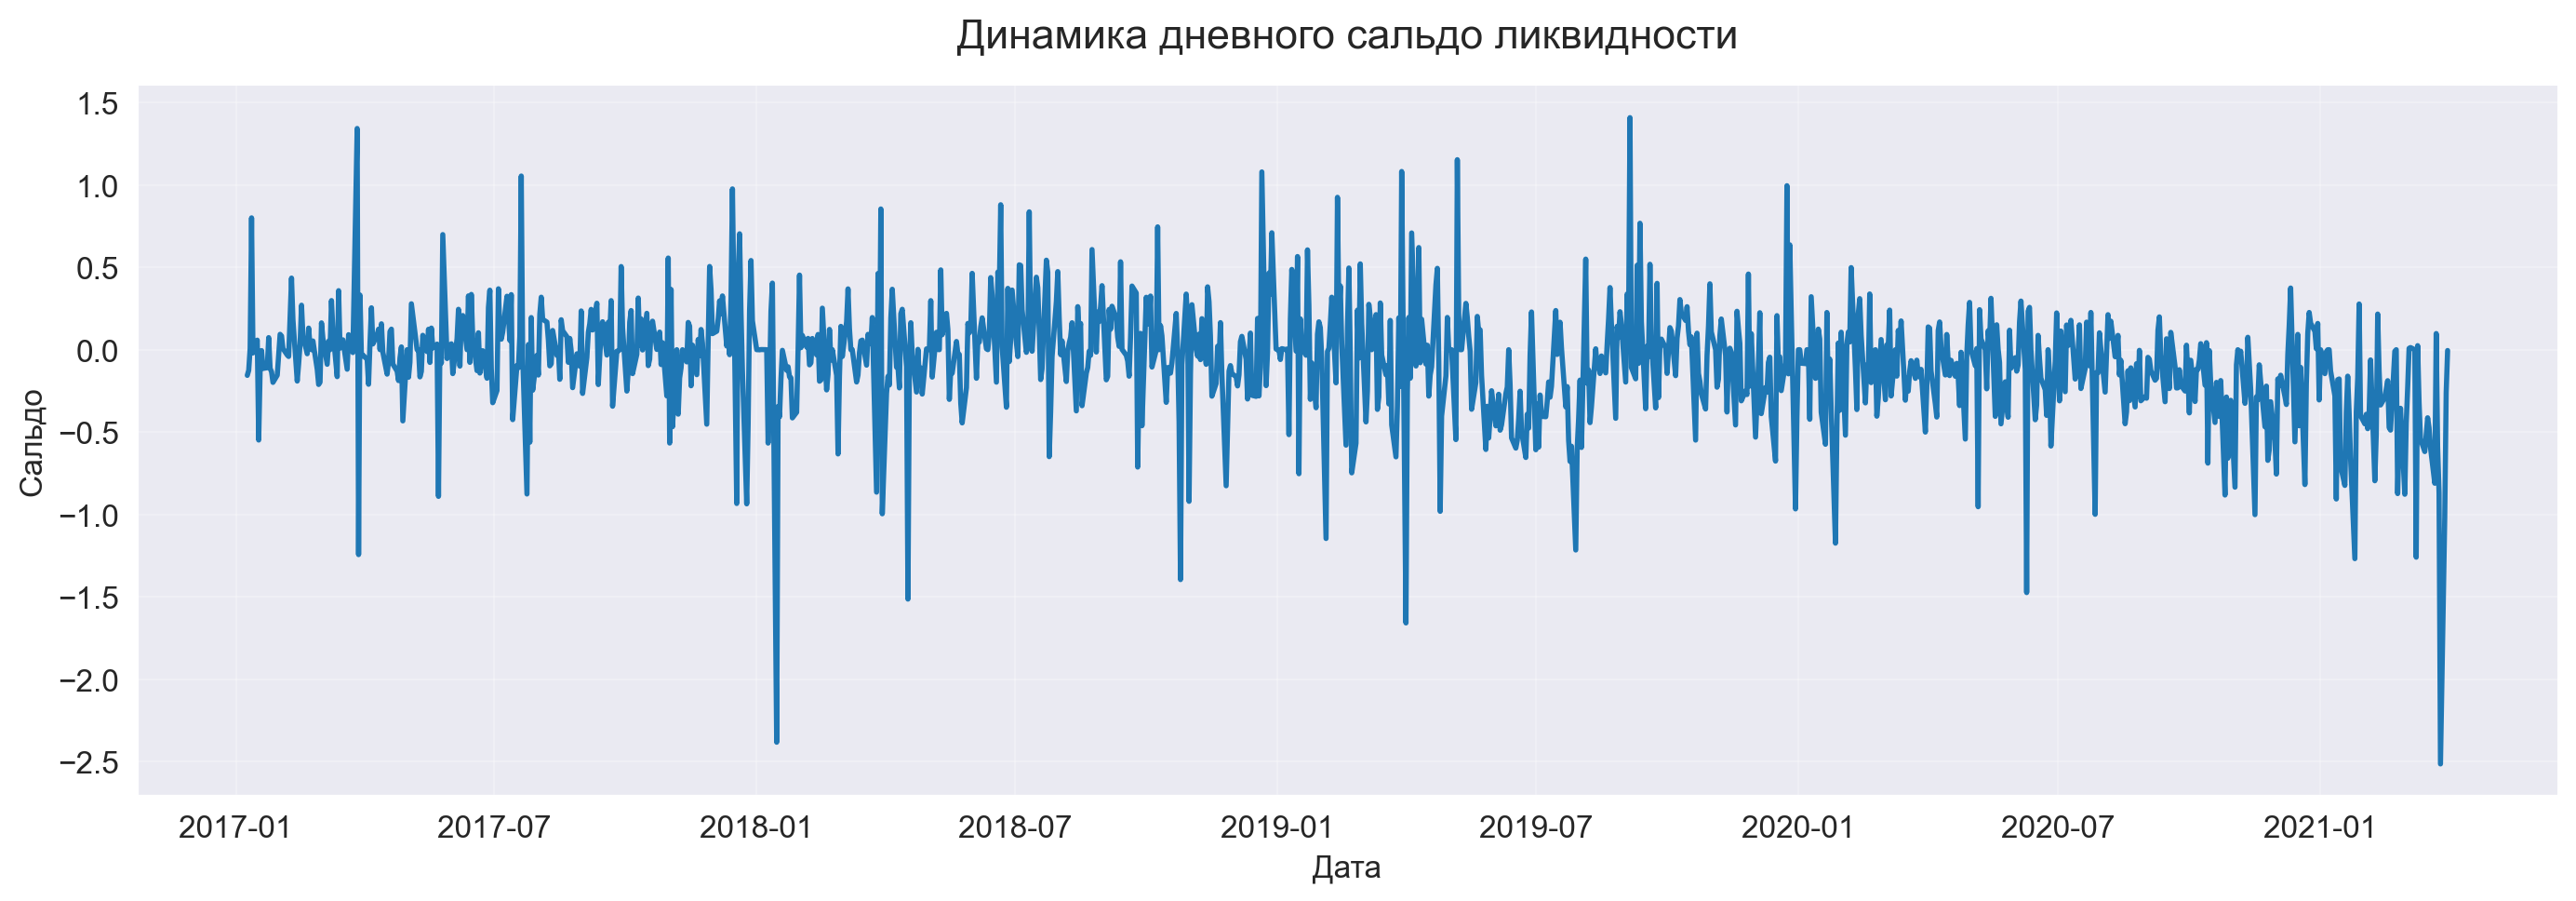

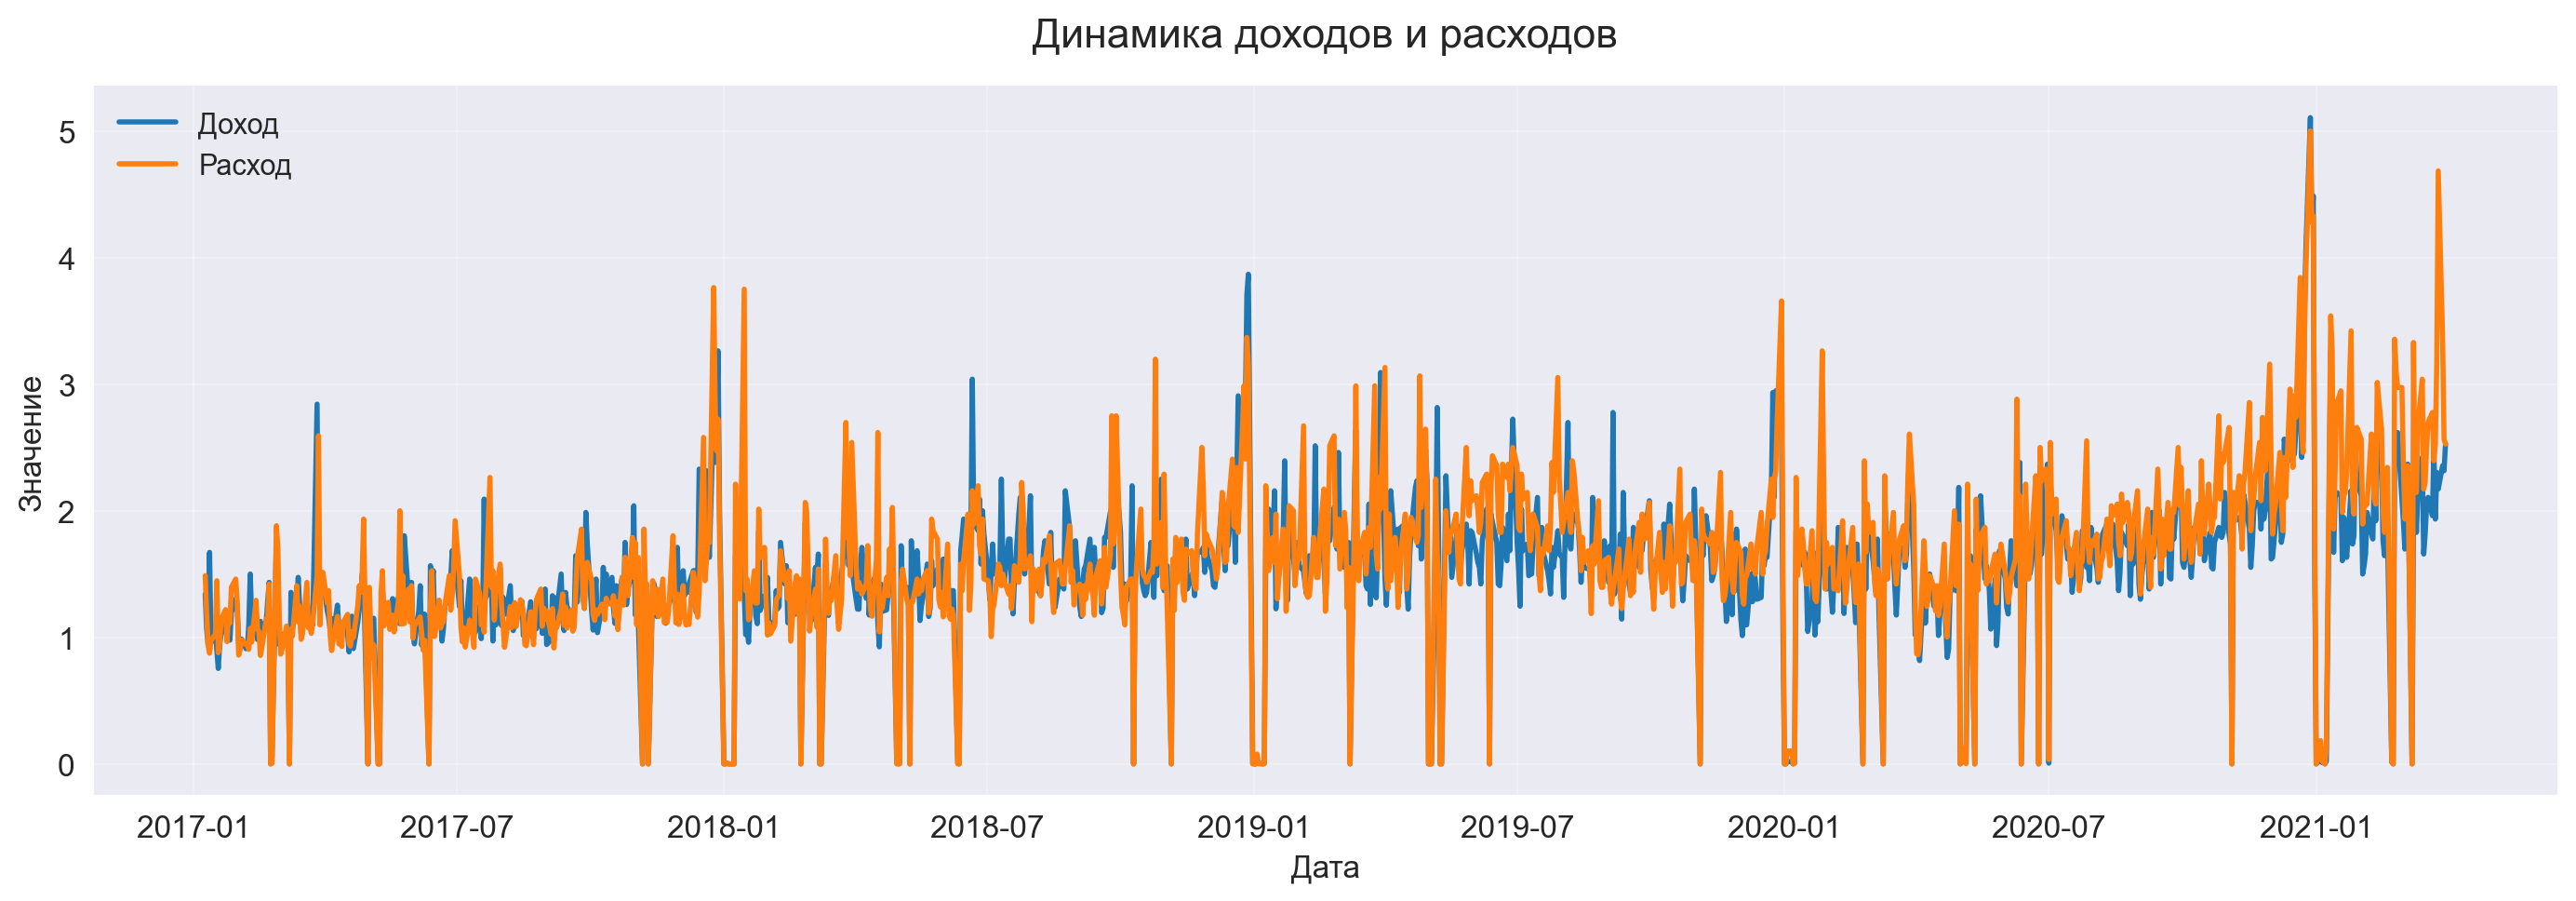

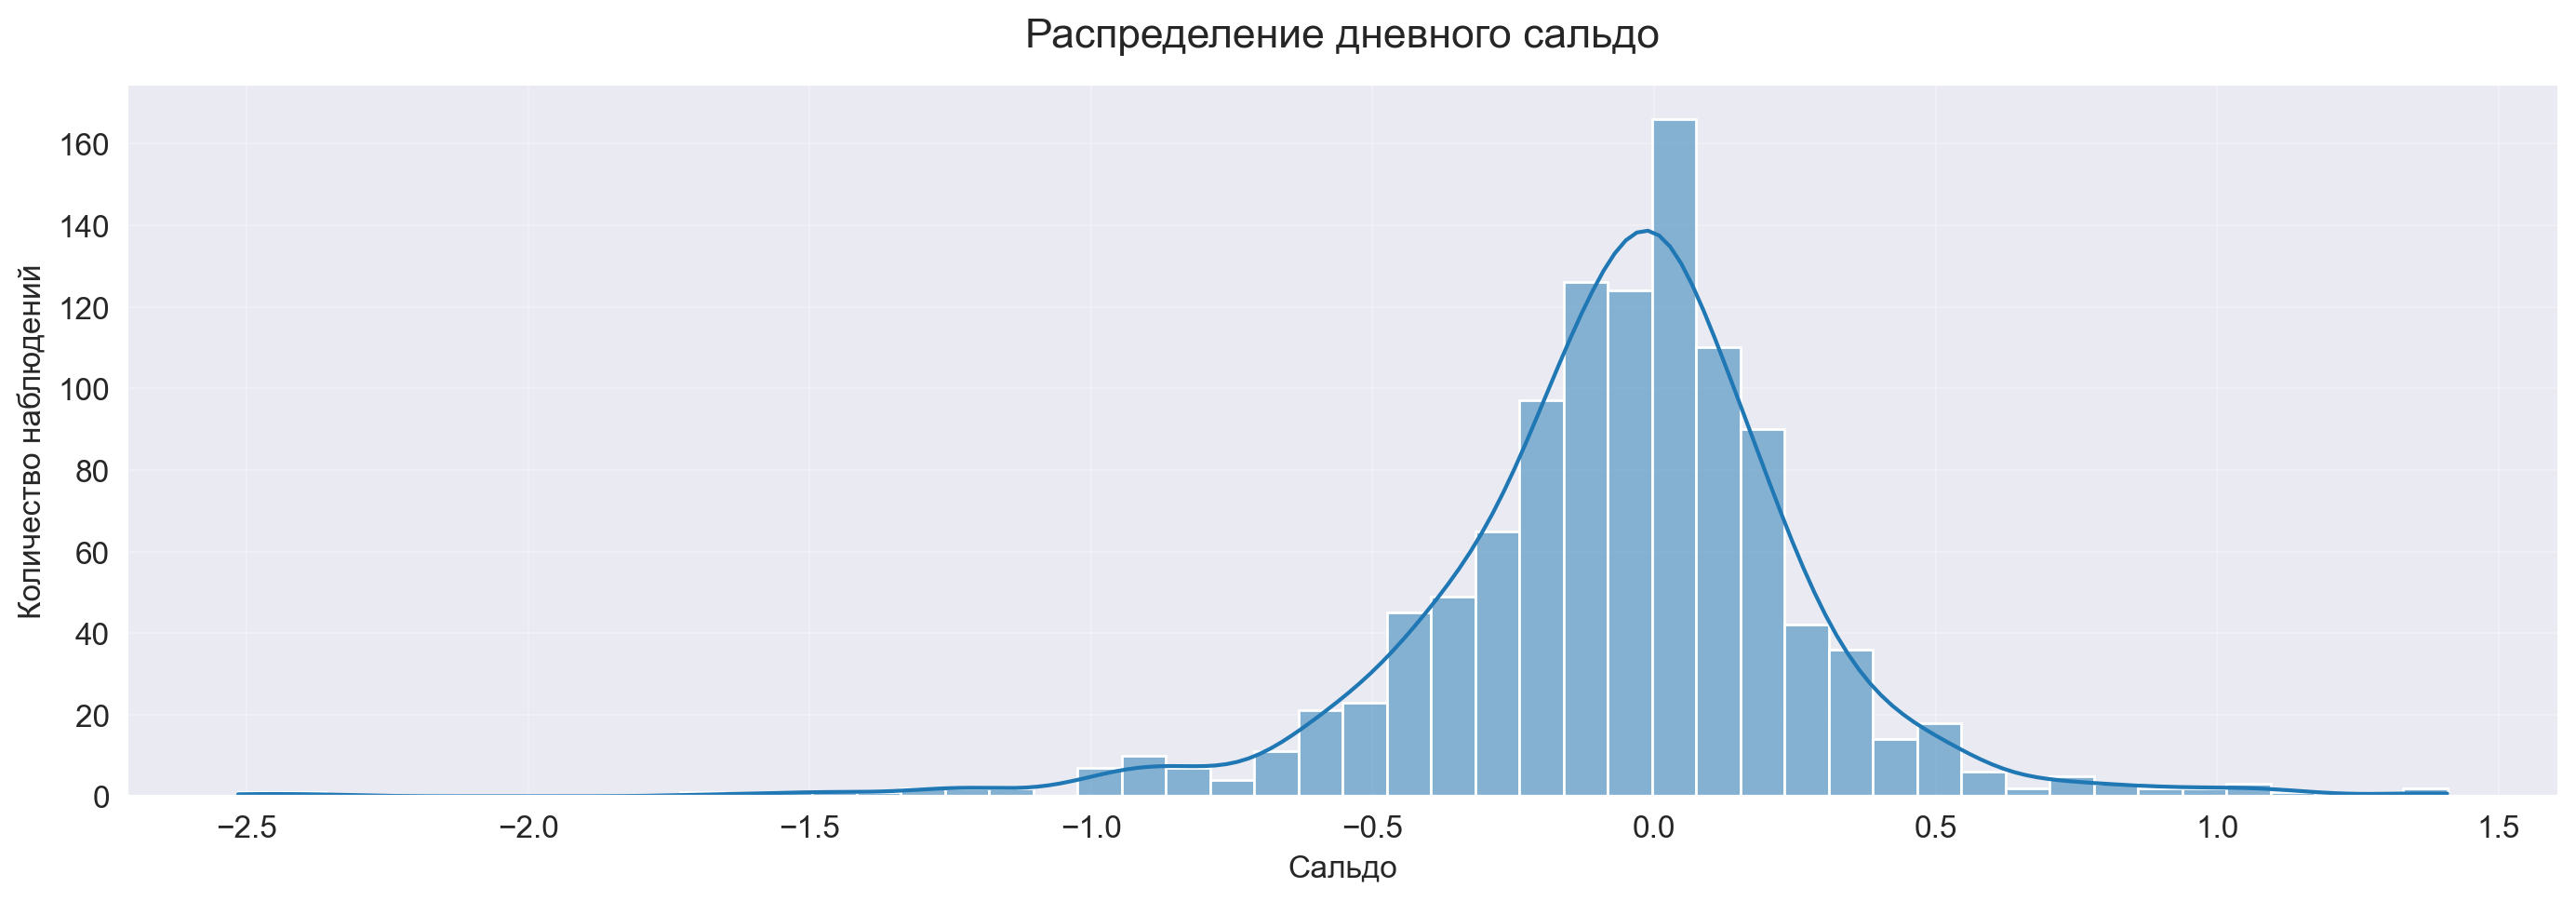

In [8]:
sns.lineplot(data=df, x="Date", y="Balance", linewidth=2)
plt.title("Динамика дневного сальдо ликвидности", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

sns.lineplot(data=df, x="Date", y="Income", linewidth=2, label="Доход")
sns.lineplot(data=df, x="Date", y="Outcome", linewidth=2, label="Расход")
plt.title("Динамика доходов и расходов", pad=15)
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

sns.histplot(data=df, x="Balance", bins=50, kde=True)
plt.title("Распределение дневного сальдо", pad=15)
plt.xlabel("Сальдо")
plt.ylabel("Количество наблюдений")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Временной ряд сальдо не имеет явного долгосрочного тренда, однако демонстрирует периодические выбросы — резкие кратковременные отклонения от нуля.
### Доходы и расходы движутся практически синхронно, сальдо формируется как разность двух близких по величине потоков, что объясняет его относительно низкую дисперсию.
### Распределение сальдо близко к нормальному с небольшой левой асимметрией и наличием тяжёлых хвостов — выбросы присутствуют с обеих сторон.

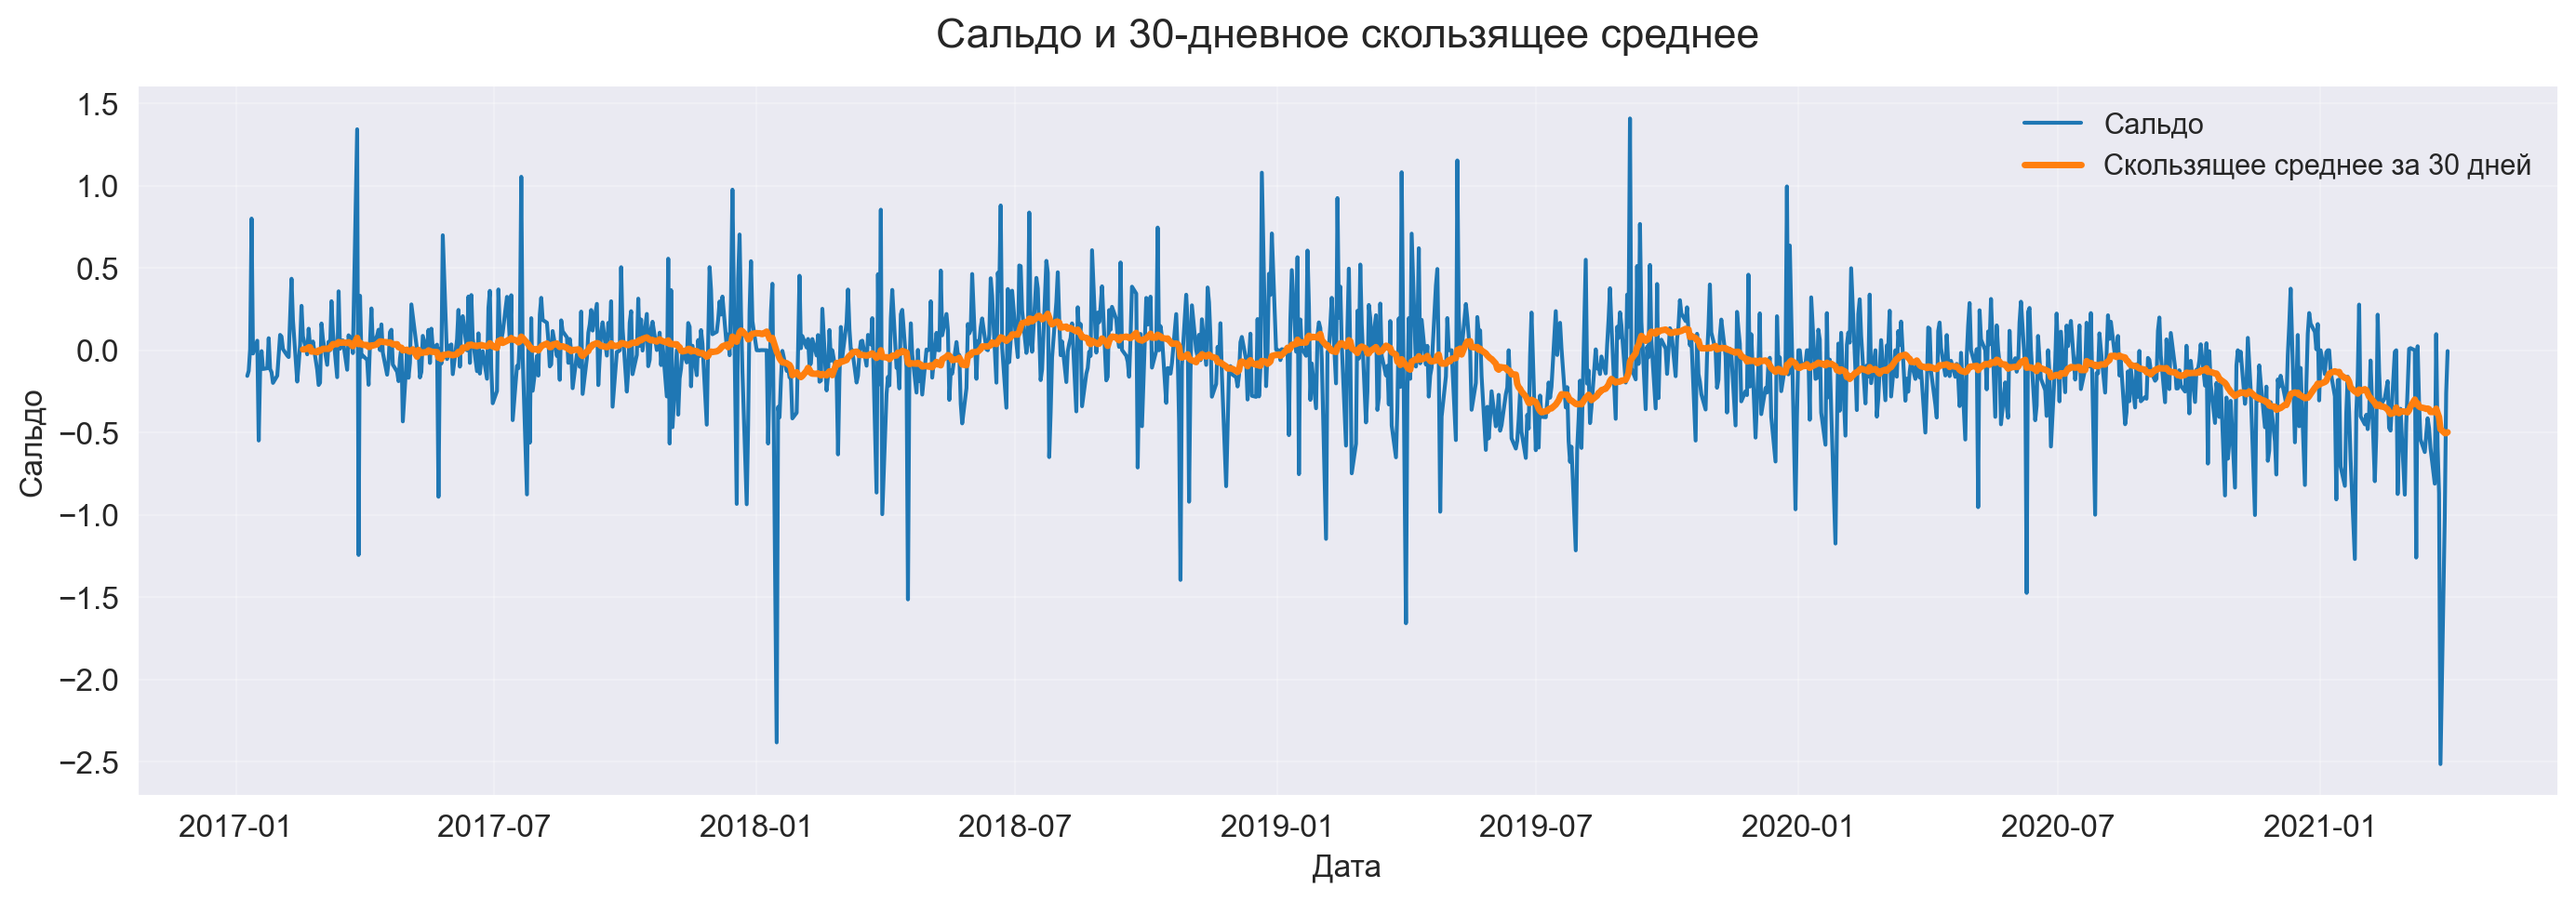

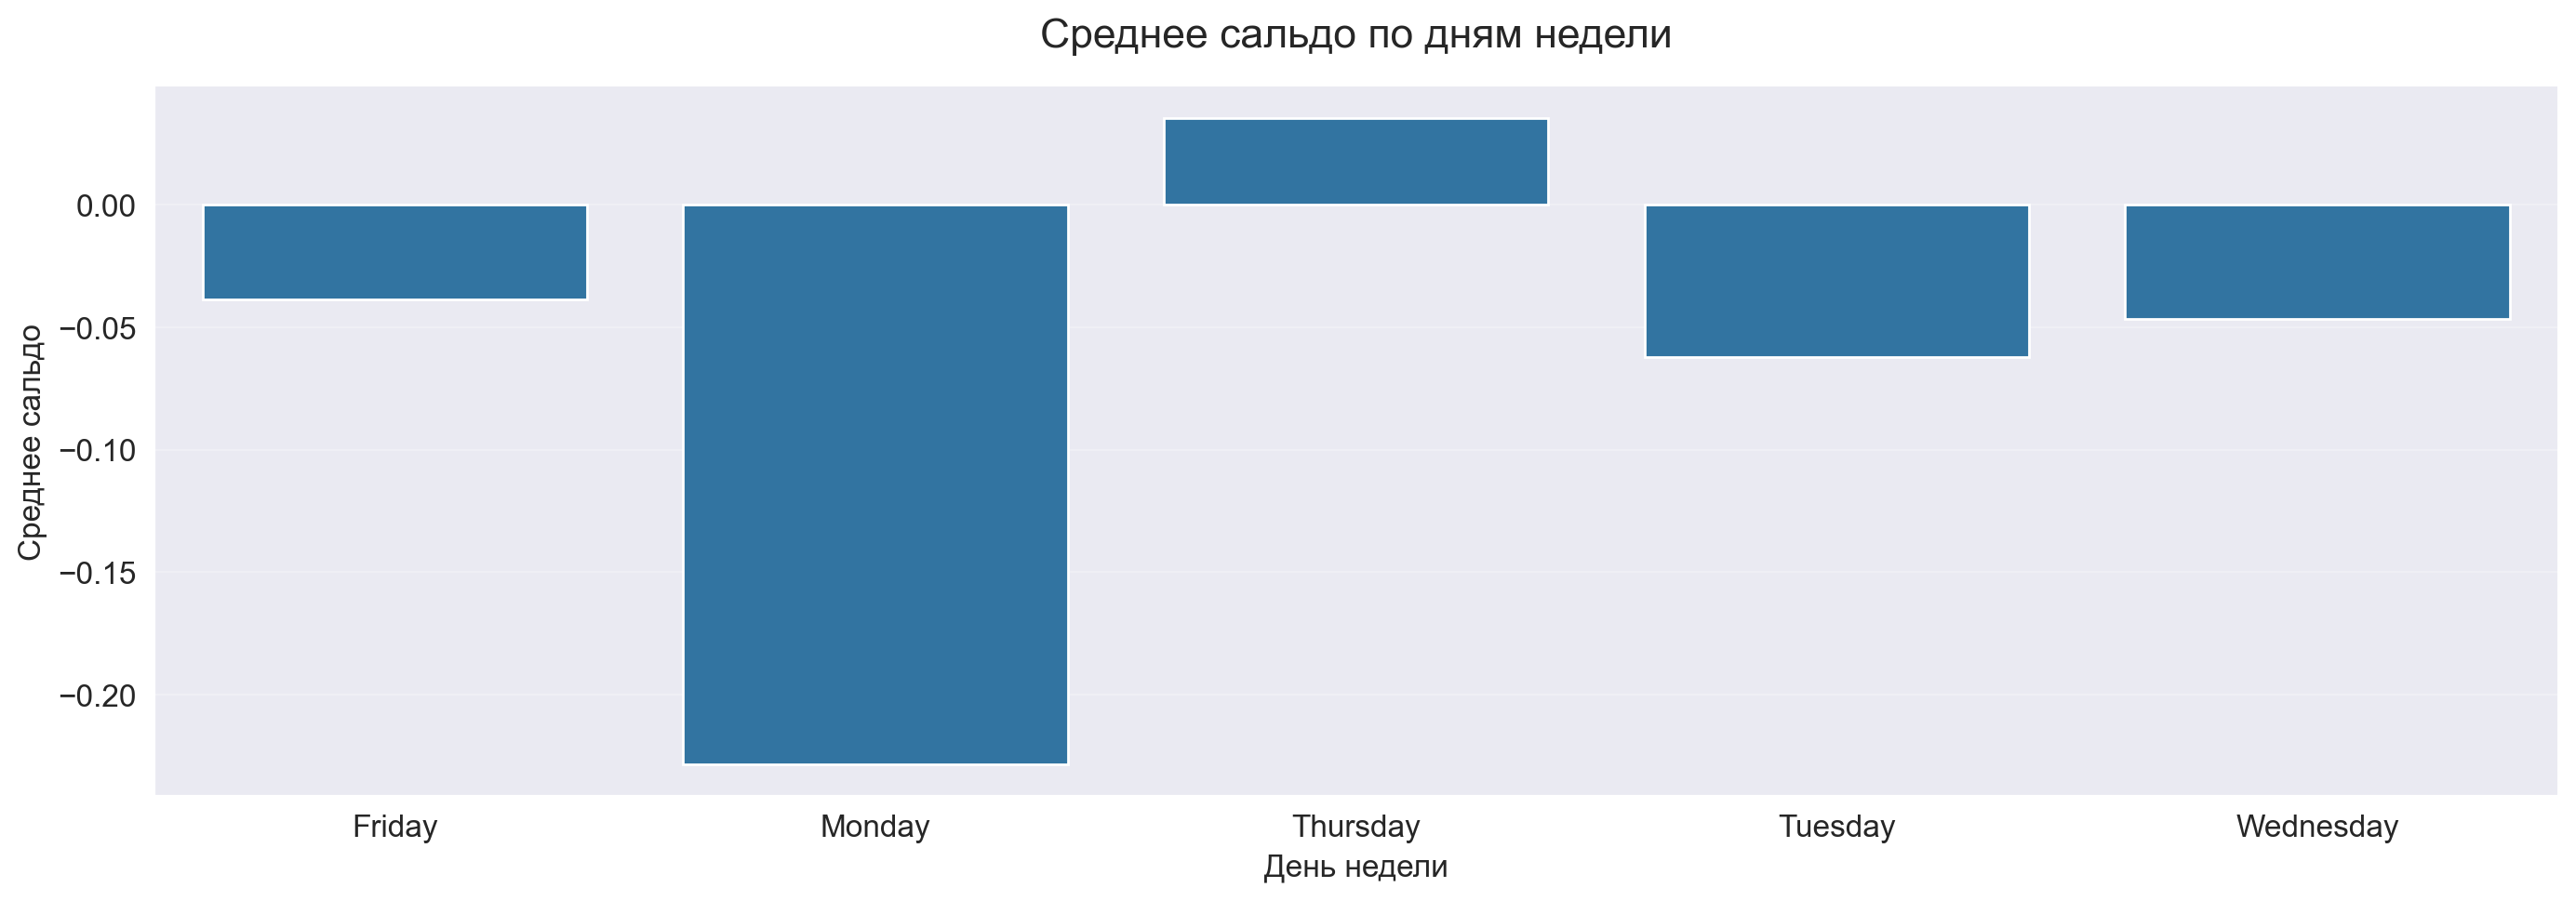

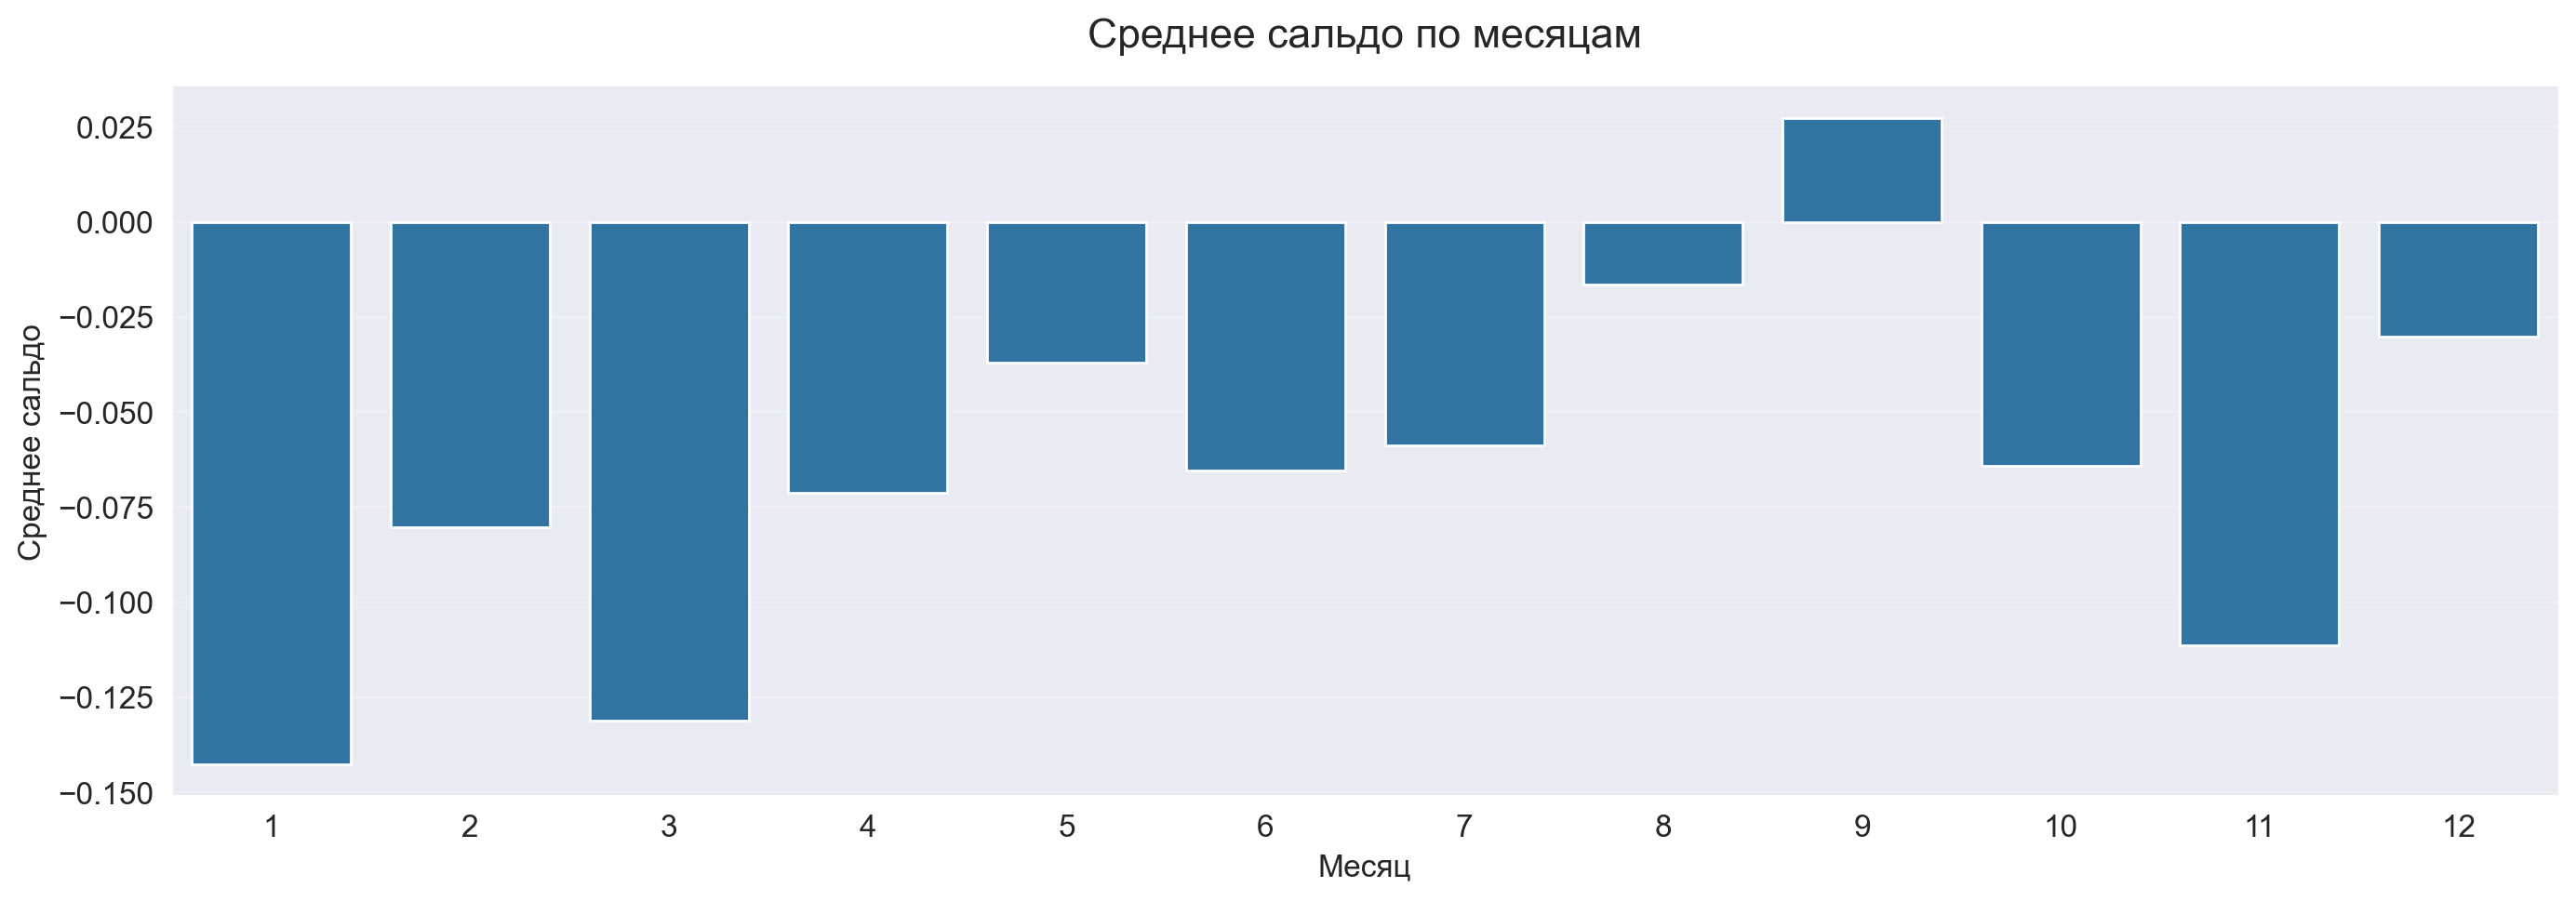

In [9]:
df["RollingMean30"] = df["Balance"].rolling(window=30).mean()

sns.lineplot(data=df, x="Date", y="Balance", linewidth=1.5, label="Сальдо")
sns.lineplot(data=df, x="Date", y="RollingMean30", linewidth=2.5, label="Скользящее среднее за 30 дней")
plt.title("Сальдо и 30-дневное скользящее среднее", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

df["DayOfWeek"] = df["Date"].dt.day_name()
weekday_stats = df.groupby("DayOfWeek", as_index=False)["Balance"].mean()

sns.barplot(data=weekday_stats, x="DayOfWeek", y="Balance")
plt.title("Среднее сальдо по дням недели", pad=15)
plt.xlabel("День недели")
plt.ylabel("Среднее сальдо")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


df["Month"] = df["Date"].dt.month
month_stats = df.groupby("Month", as_index=False)["Balance"].mean()

sns.barplot(data=month_stats, x="Month", y="Balance")
plt.title("Среднее сальдо по месяцам", pad=15)
plt.xlabel("Месяц")
plt.ylabel("Среднее сальдо")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Скользящее среднее за 30 дней остаётся стабильным на протяжении всего периода, подтверждая отсутствие долгосрочного тренда.
### По дням недели прослеживается слабая закономерность: в начале недели сальдо незначительно выше, к концу — ниже, что указывает на наличие недельного сезонного паттерна.
### По месяцам наблюдается неравномерность: отдельные месяцы демонстрируют отклонения от среднего, что может быть связано с налоговыми и отчётными периодами.

# Разладки
## Для обнаружения разладок применяется метод кумулятивных сумм

In [10]:
series = df.set_index("Date")["Balance"]

cusum_result, changepoints = detect_changepoints(
    series=series,
    threshold=5,
    drift=0.5
)

changepoints

DatetimeIndex(['2017-12-15', '2018-01-15', '2018-07-05', '2018-12-28',
               '2019-06-07', '2019-06-24', '2019-07-29', '2019-09-12',
               '2020-10-29', '2020-11-27', '2021-01-19', '2021-01-26',
               '2021-02-24', '2021-03-15', '2021-03-25', '2021-03-26'],
              dtype='datetime64[us]', name='Date', freq=None)

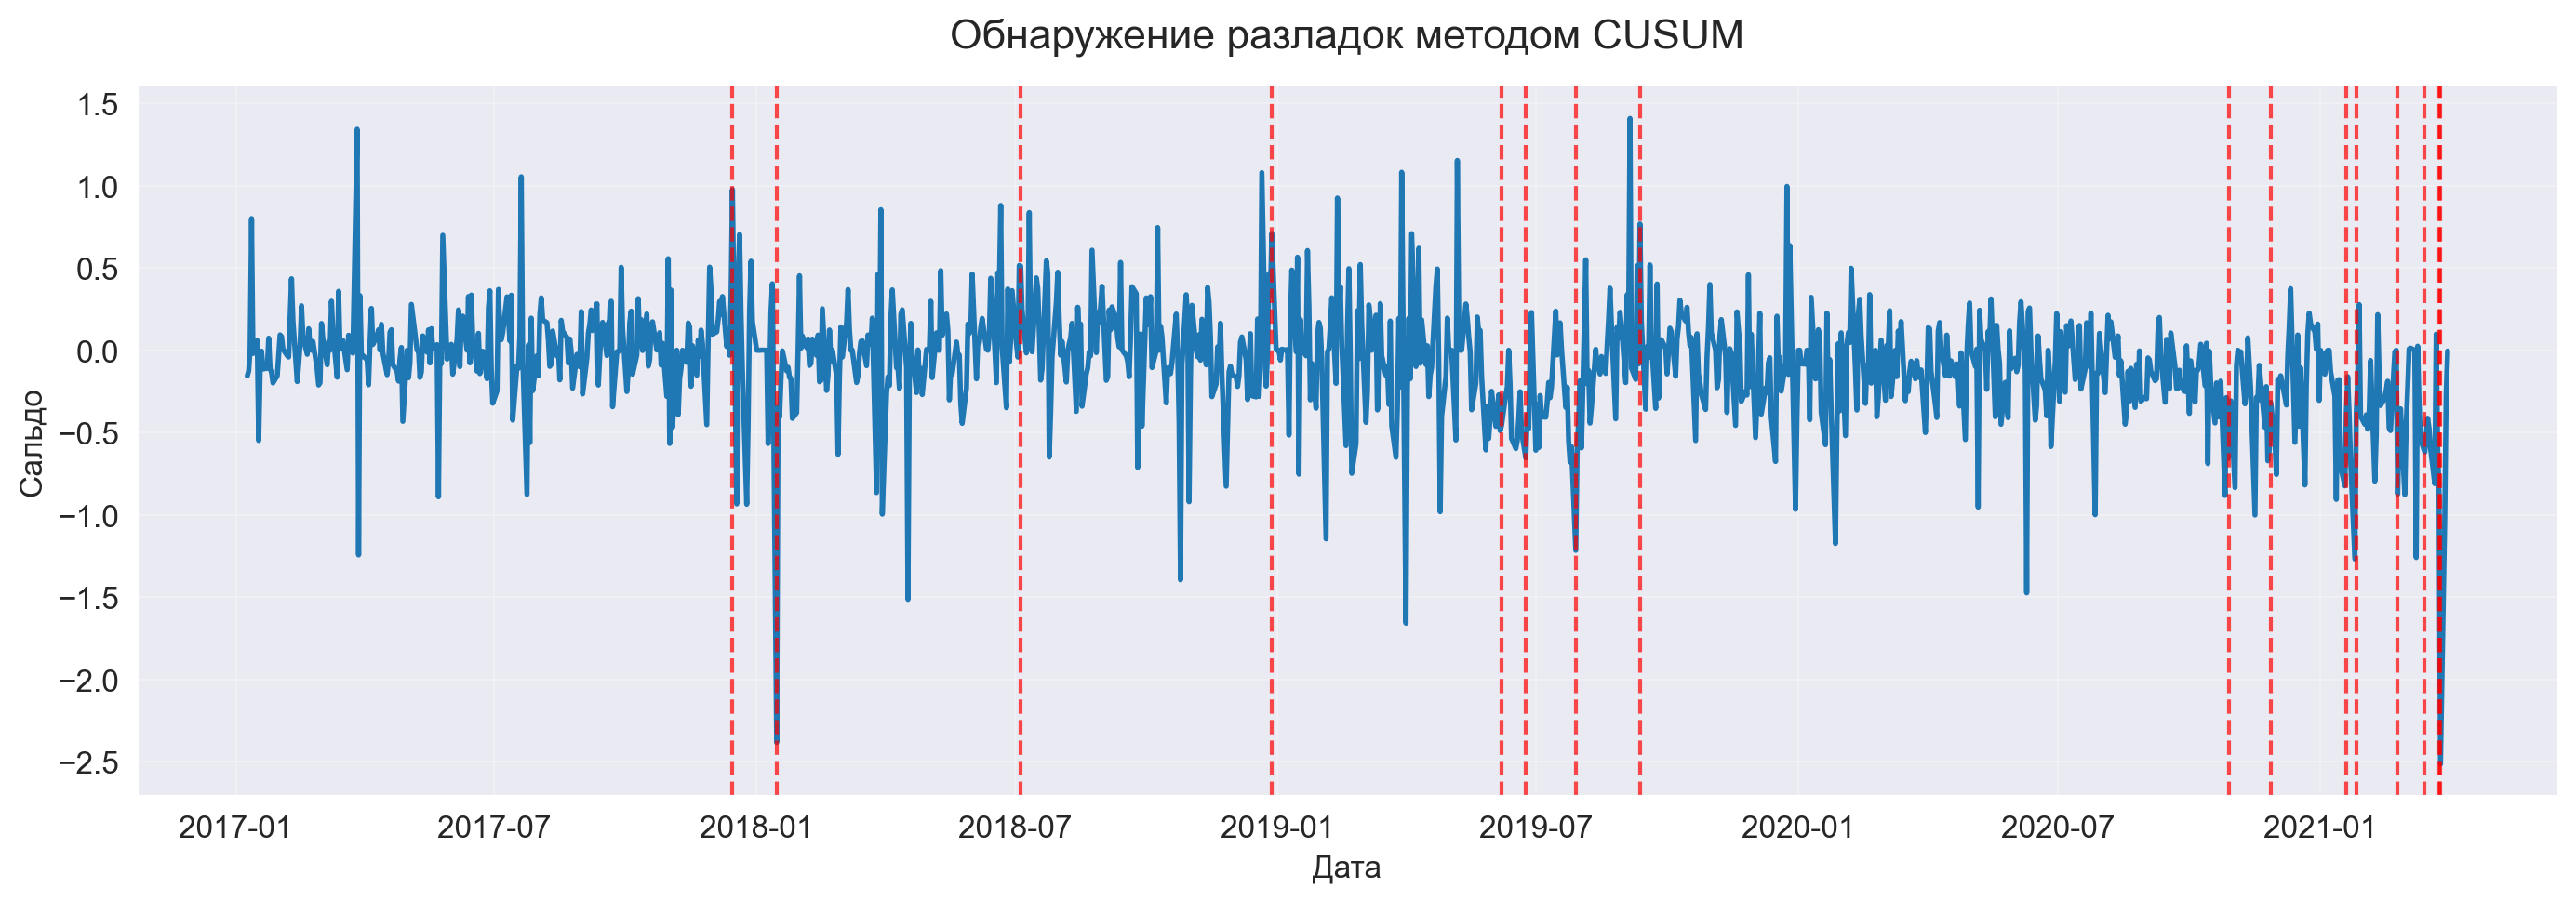

In [11]:
sns.lineplot(x=cusum_result.index, y=cusum_result["Value"], linewidth=2)

for point in changepoints:
    plt.axvline(x=point, linestyle="--", alpha=0.7, color="red")

plt.title("Обнаружение разладок методом CUSUM", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Метод CUSUM выявил ряд потенциальных точек изменения процесса.

### Визуальный анализ показал, что большинство обнаруженных событий связано с отдельными экстремальными наблюдениями, а не с устойчивым изменением статистических свойств ряда.

### Существенных структурных разладок, приводящих к смене режима функционирования процесса, обнаружено не было. Следовательно, временной ряд может рассматриваться как относительно однородный на рассматриваемом временном интервале.

# Авторегрессионные модели
## Проверяется стационарность ряда, возможность применимости моделей, подбор параметров

In [12]:
# Анализ стационарности ряда
series = df.set_index("Date")["Balance"]
series = df.set_index("Date")["Balance"].dropna()
adf_result = adfuller(series)

print("ADF-тест")
print("-" * 40)
print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("Ряд можно считать стационарным, дифференцирование может не потребоваться.")
else:
    print("Ряд нестационарен, рекомендуется использовать дифференцирование.")

ADF-тест
----------------------------------------
ADF statistic: -3.1544
p-value: 0.0228
Ряд можно считать стационарным, дифференцирование может не потребоваться.


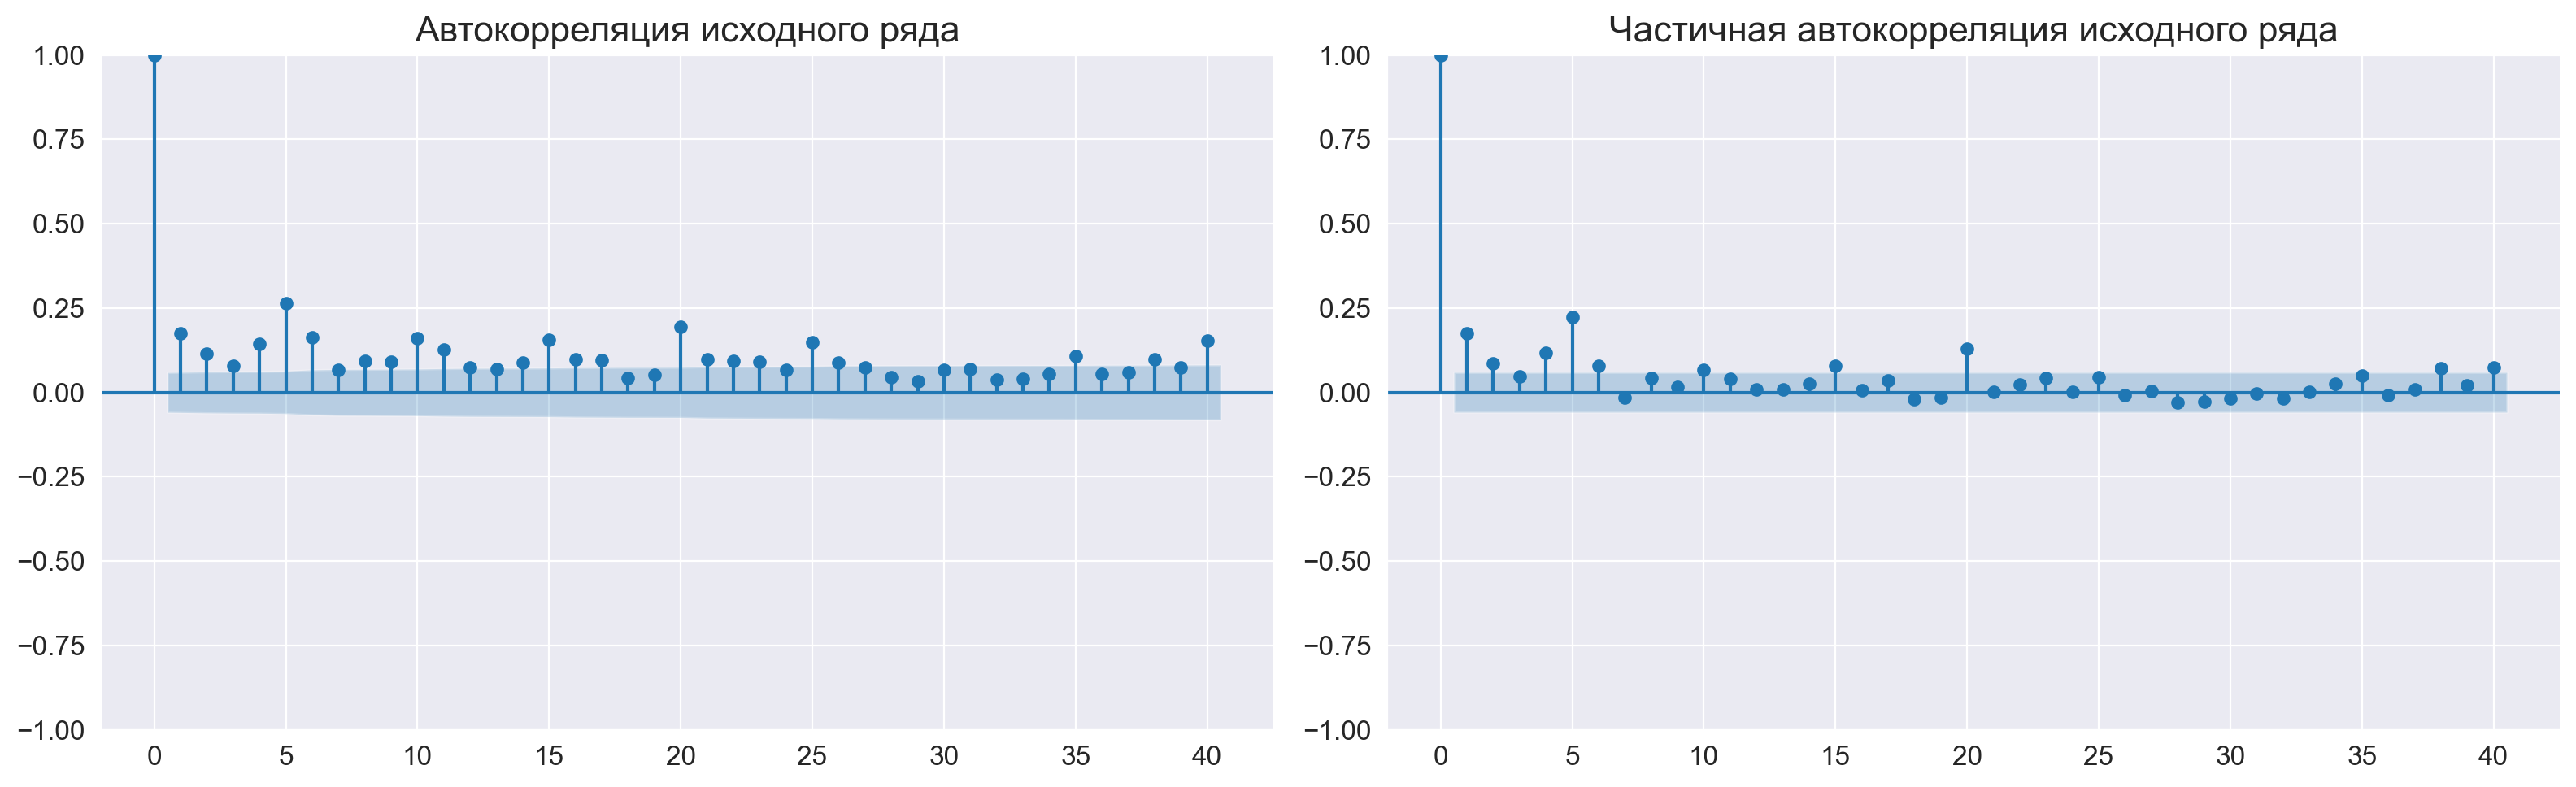

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(series, lags=40, ax=axes[0])

axes[0].set_title("Автокорреляция исходного ряда")

plot_pacf(series, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Частичная автокорреляция исходного ряда")

plt.tight_layout()
plt.show()

По левому графику можно понять, что q можно брать равным 1 или 2 \
По правому графику видно, что p стоит попробовать также равным 1 или 2 \
Ряд стационарен, поэтому d = 0 \
\
Итого получилась модель ARIMA(1, 0, 1)

## ARIMA

In [14]:
series = df.set_index("Date")["Balance"]

tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(series))
train_idx, test_idx = splits[-1]

y_train = series.iloc[train_idx]
y_test = series.iloc[test_idx]

print(f"Размер обучающей выборки: {len(y_train)}")
print(f"Размер тестовой выборки: {len(y_test)}")
print("\nПериод обучения:")
print(y_train.index.min(), "-", y_train.index.max())
print("\nПериод тестирования:")
print(y_test.index.min(), "-", y_test.index.max())

Размер обучающей выборки: 920
Размер тестовой выборки: 183

Период обучения:
2017-01-09 00:00:00 - 2020-07-17 00:00:00

Период тестирования:
2020-07-20 00:00:00 - 2021-03-31 00:00:00


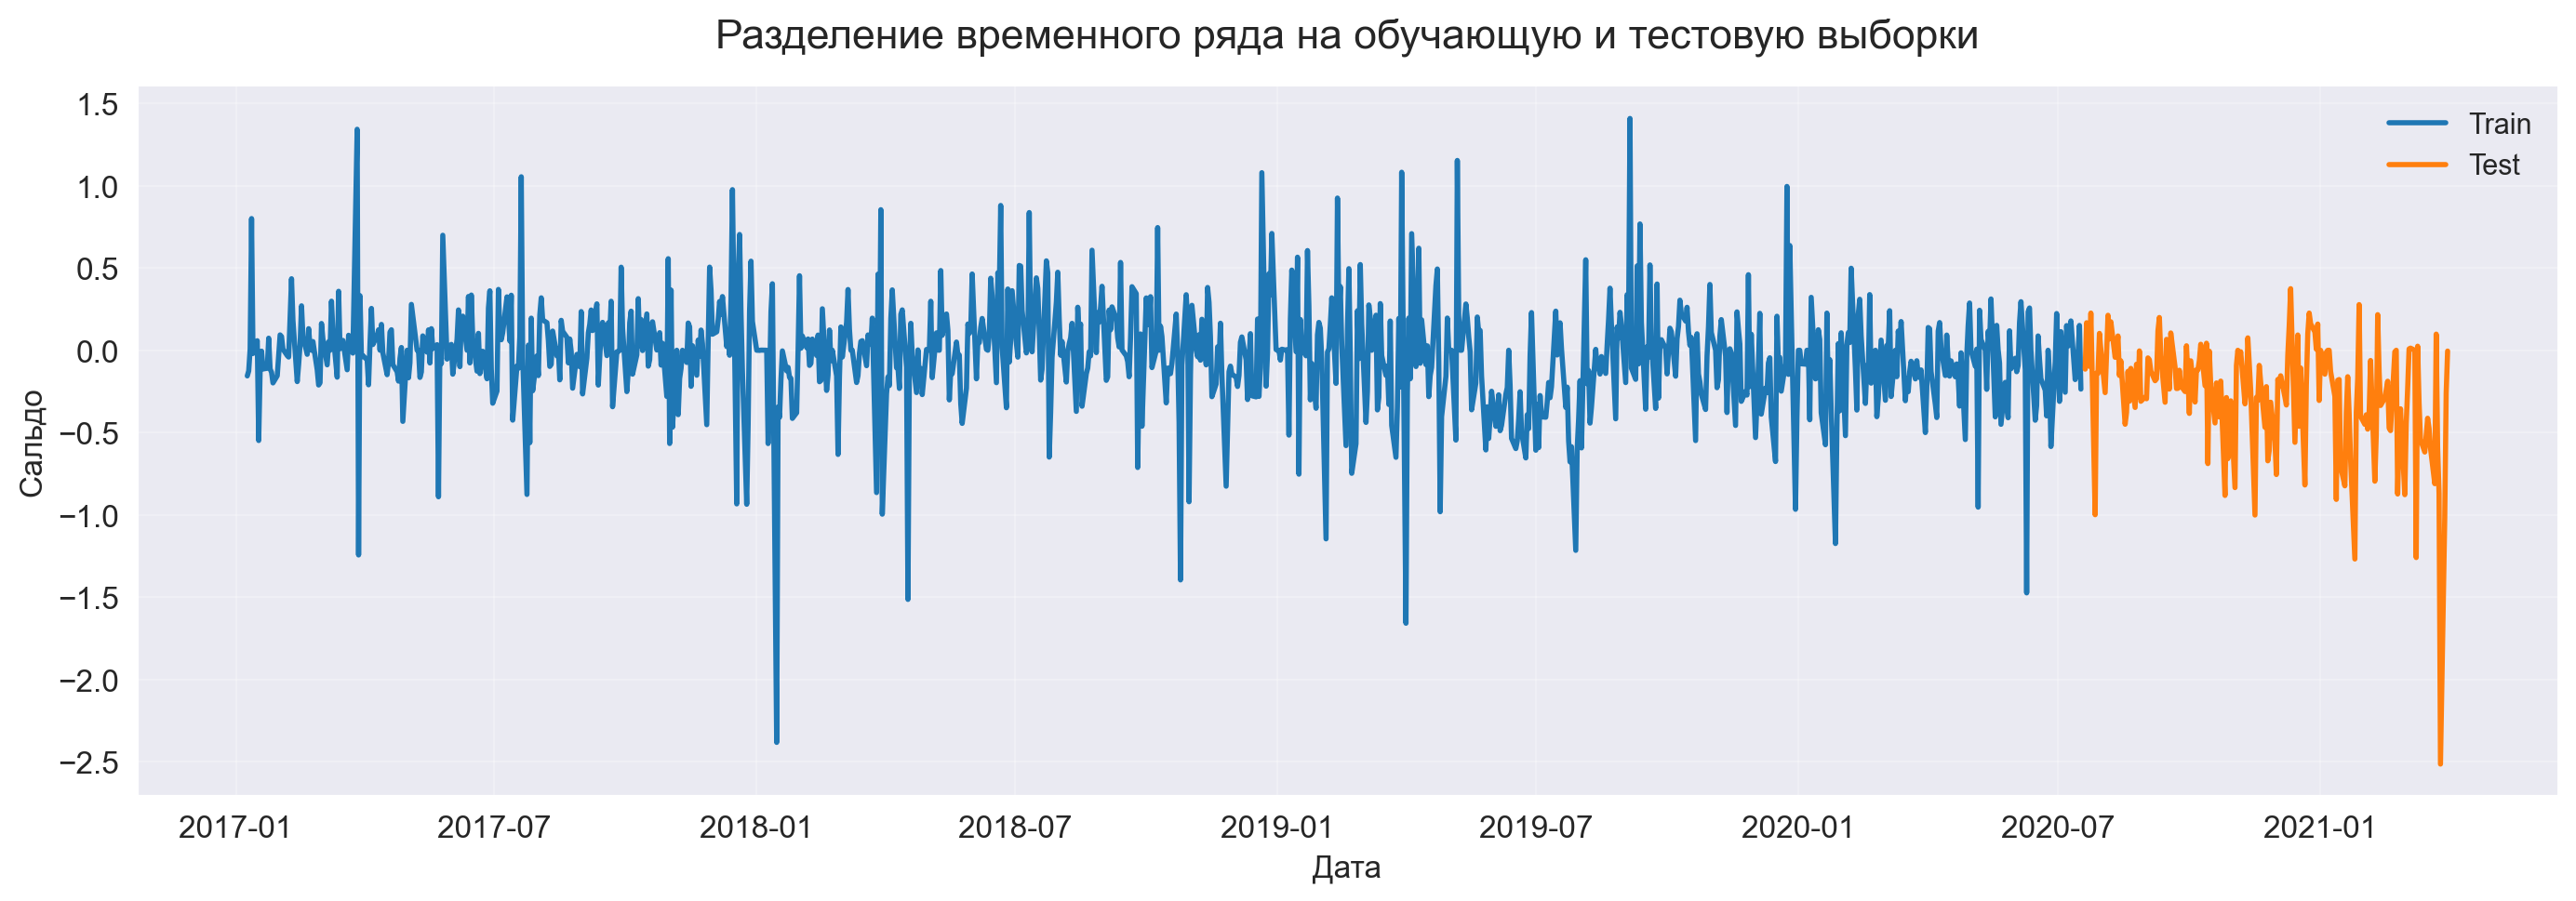

In [15]:
sns.lineplot(x=y_train.index, y=y_train.values, label="Train", linewidth=2)
sns.lineplot(x=y_test.index, y=y_test.values, label="Test", linewidth=2)
plt.title("Разделение временного ряда на обучающую и тестовую выборки", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Обучающая выборка охватывает период с января 2017 по июль 2020 года (920 наблюдений), тестовая — с июля 2020 по март 2021 года (183 наблюдения).
### Тестовый период приходится на нестабильную рыночную обстановку, что является дополнительной проверкой устойчивости модели к внешним шокам.

In [16]:
arima_model, arima_result, arima_metrics = run_arima(y_train=y_train, y_test=y_test, p=1, d=0, q=1)

arima_metrics

{'MAE': 0.2322531393005645}

### Результат получается примерно одинаковый при других наборах p и q

# Сравнение с бейзлайном

In [17]:
baseline_result, baseline_metrics = run_mean_baseline(y_train=y_train, y_test=y_test)

print("Baseline MAE:")
print(baseline_metrics)

Baseline MAE:
{'MAE': 0.2806629547871521}


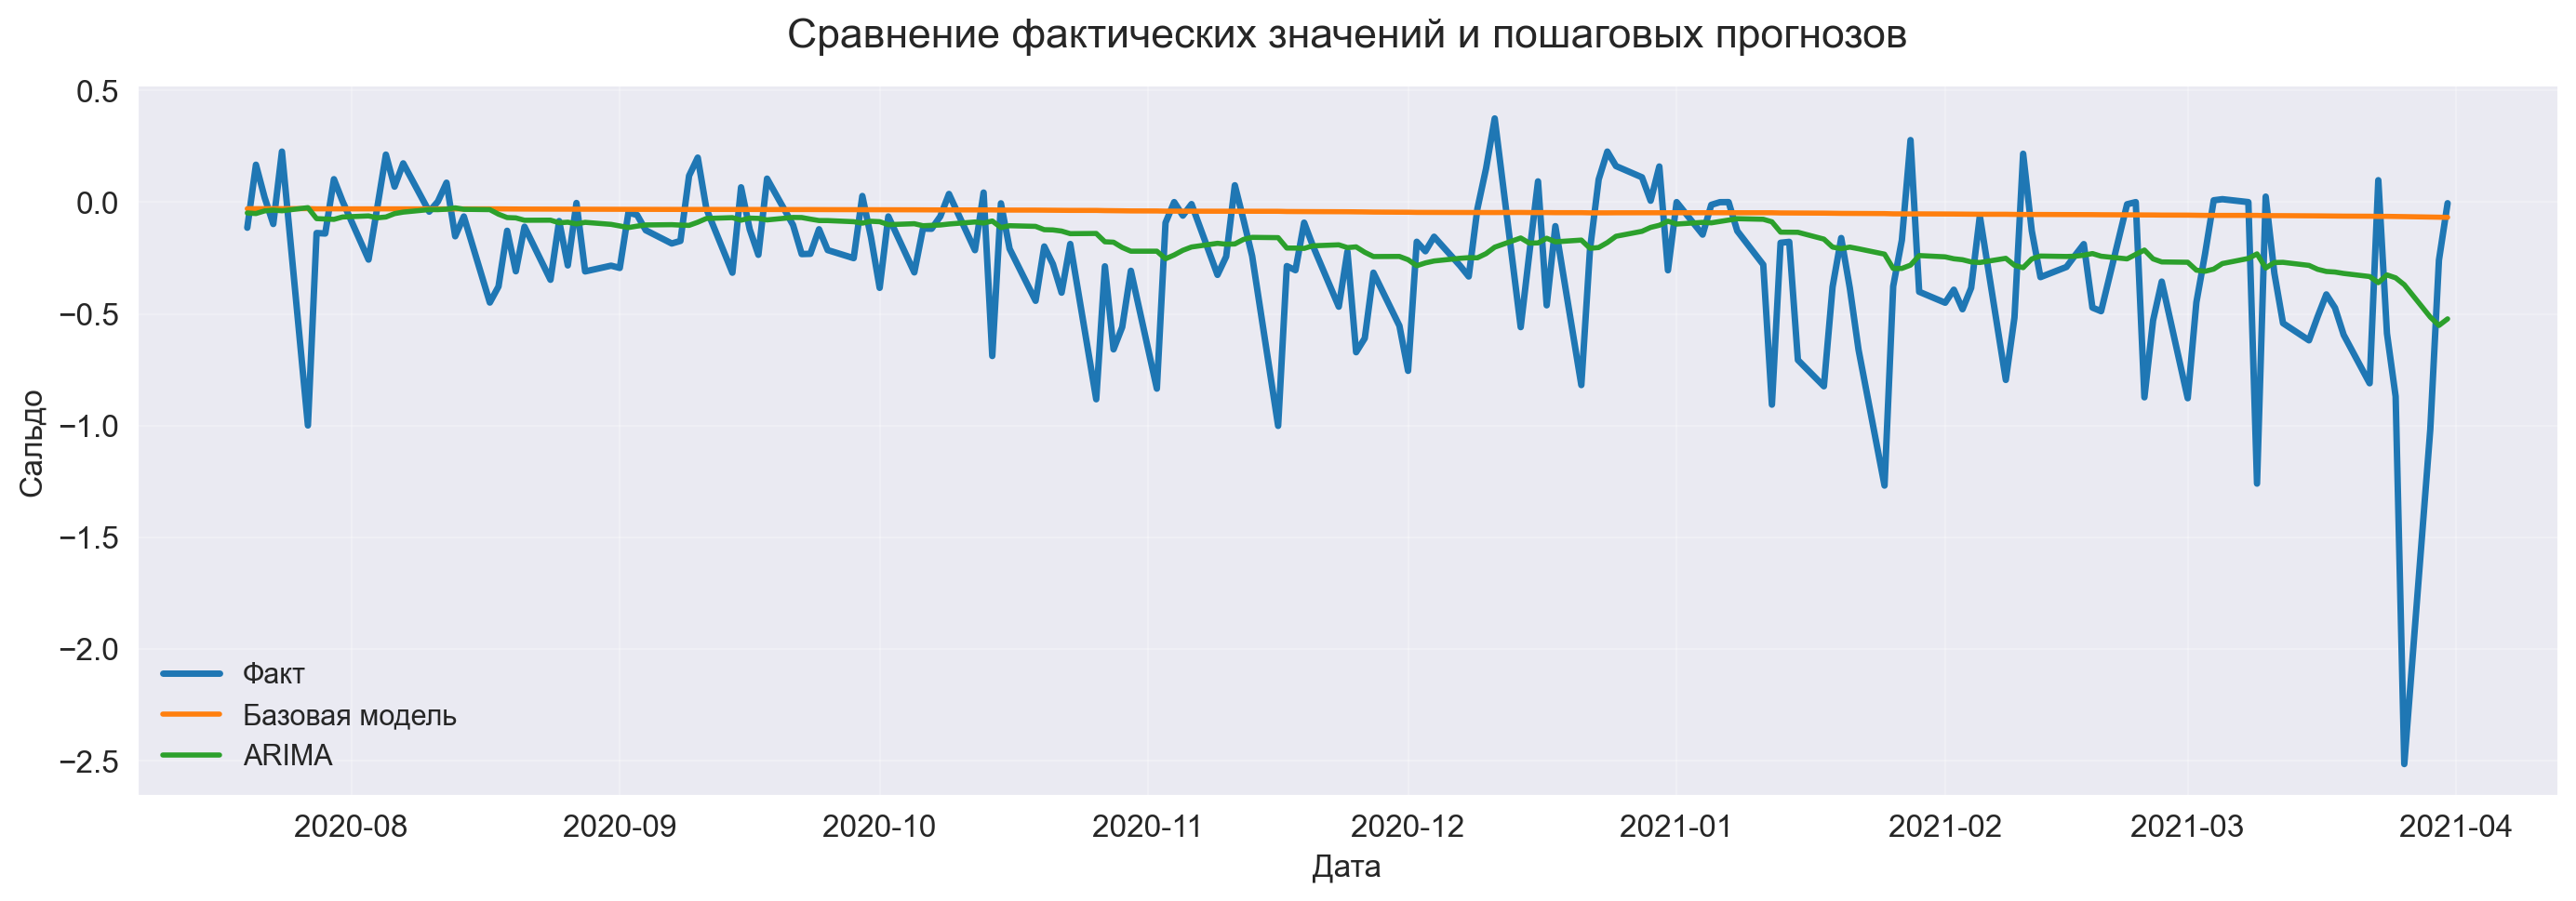

In [18]:
comparison_df = pd.DataFrame({
    "Факт": y_test.values,
    "Базовая модель": baseline_result["Predicted"].values,
    "ARIMA": arima_result["Predicted"].values
}, index=y_test.index)

sns.lineplot(x=comparison_df.index, y=comparison_df["Факт"], label="Факт", linewidth=2.5)
sns.lineplot(x=comparison_df.index, y=comparison_df["Базовая модель"], label="Базовая модель", linewidth=2)
sns.lineplot(x=comparison_df.index, y=comparison_df["ARIMA"], label="ARIMA", linewidth=2)
plt.title("Сравнение фактических значений и пошаговых прогнозов", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Предсказание с помощью ARIMA получилось лучше бейзлайна
## Бейзлайн модель уже удовлетворяет условию заказчика

# SARIMA
## Проверяем наличие сезонности

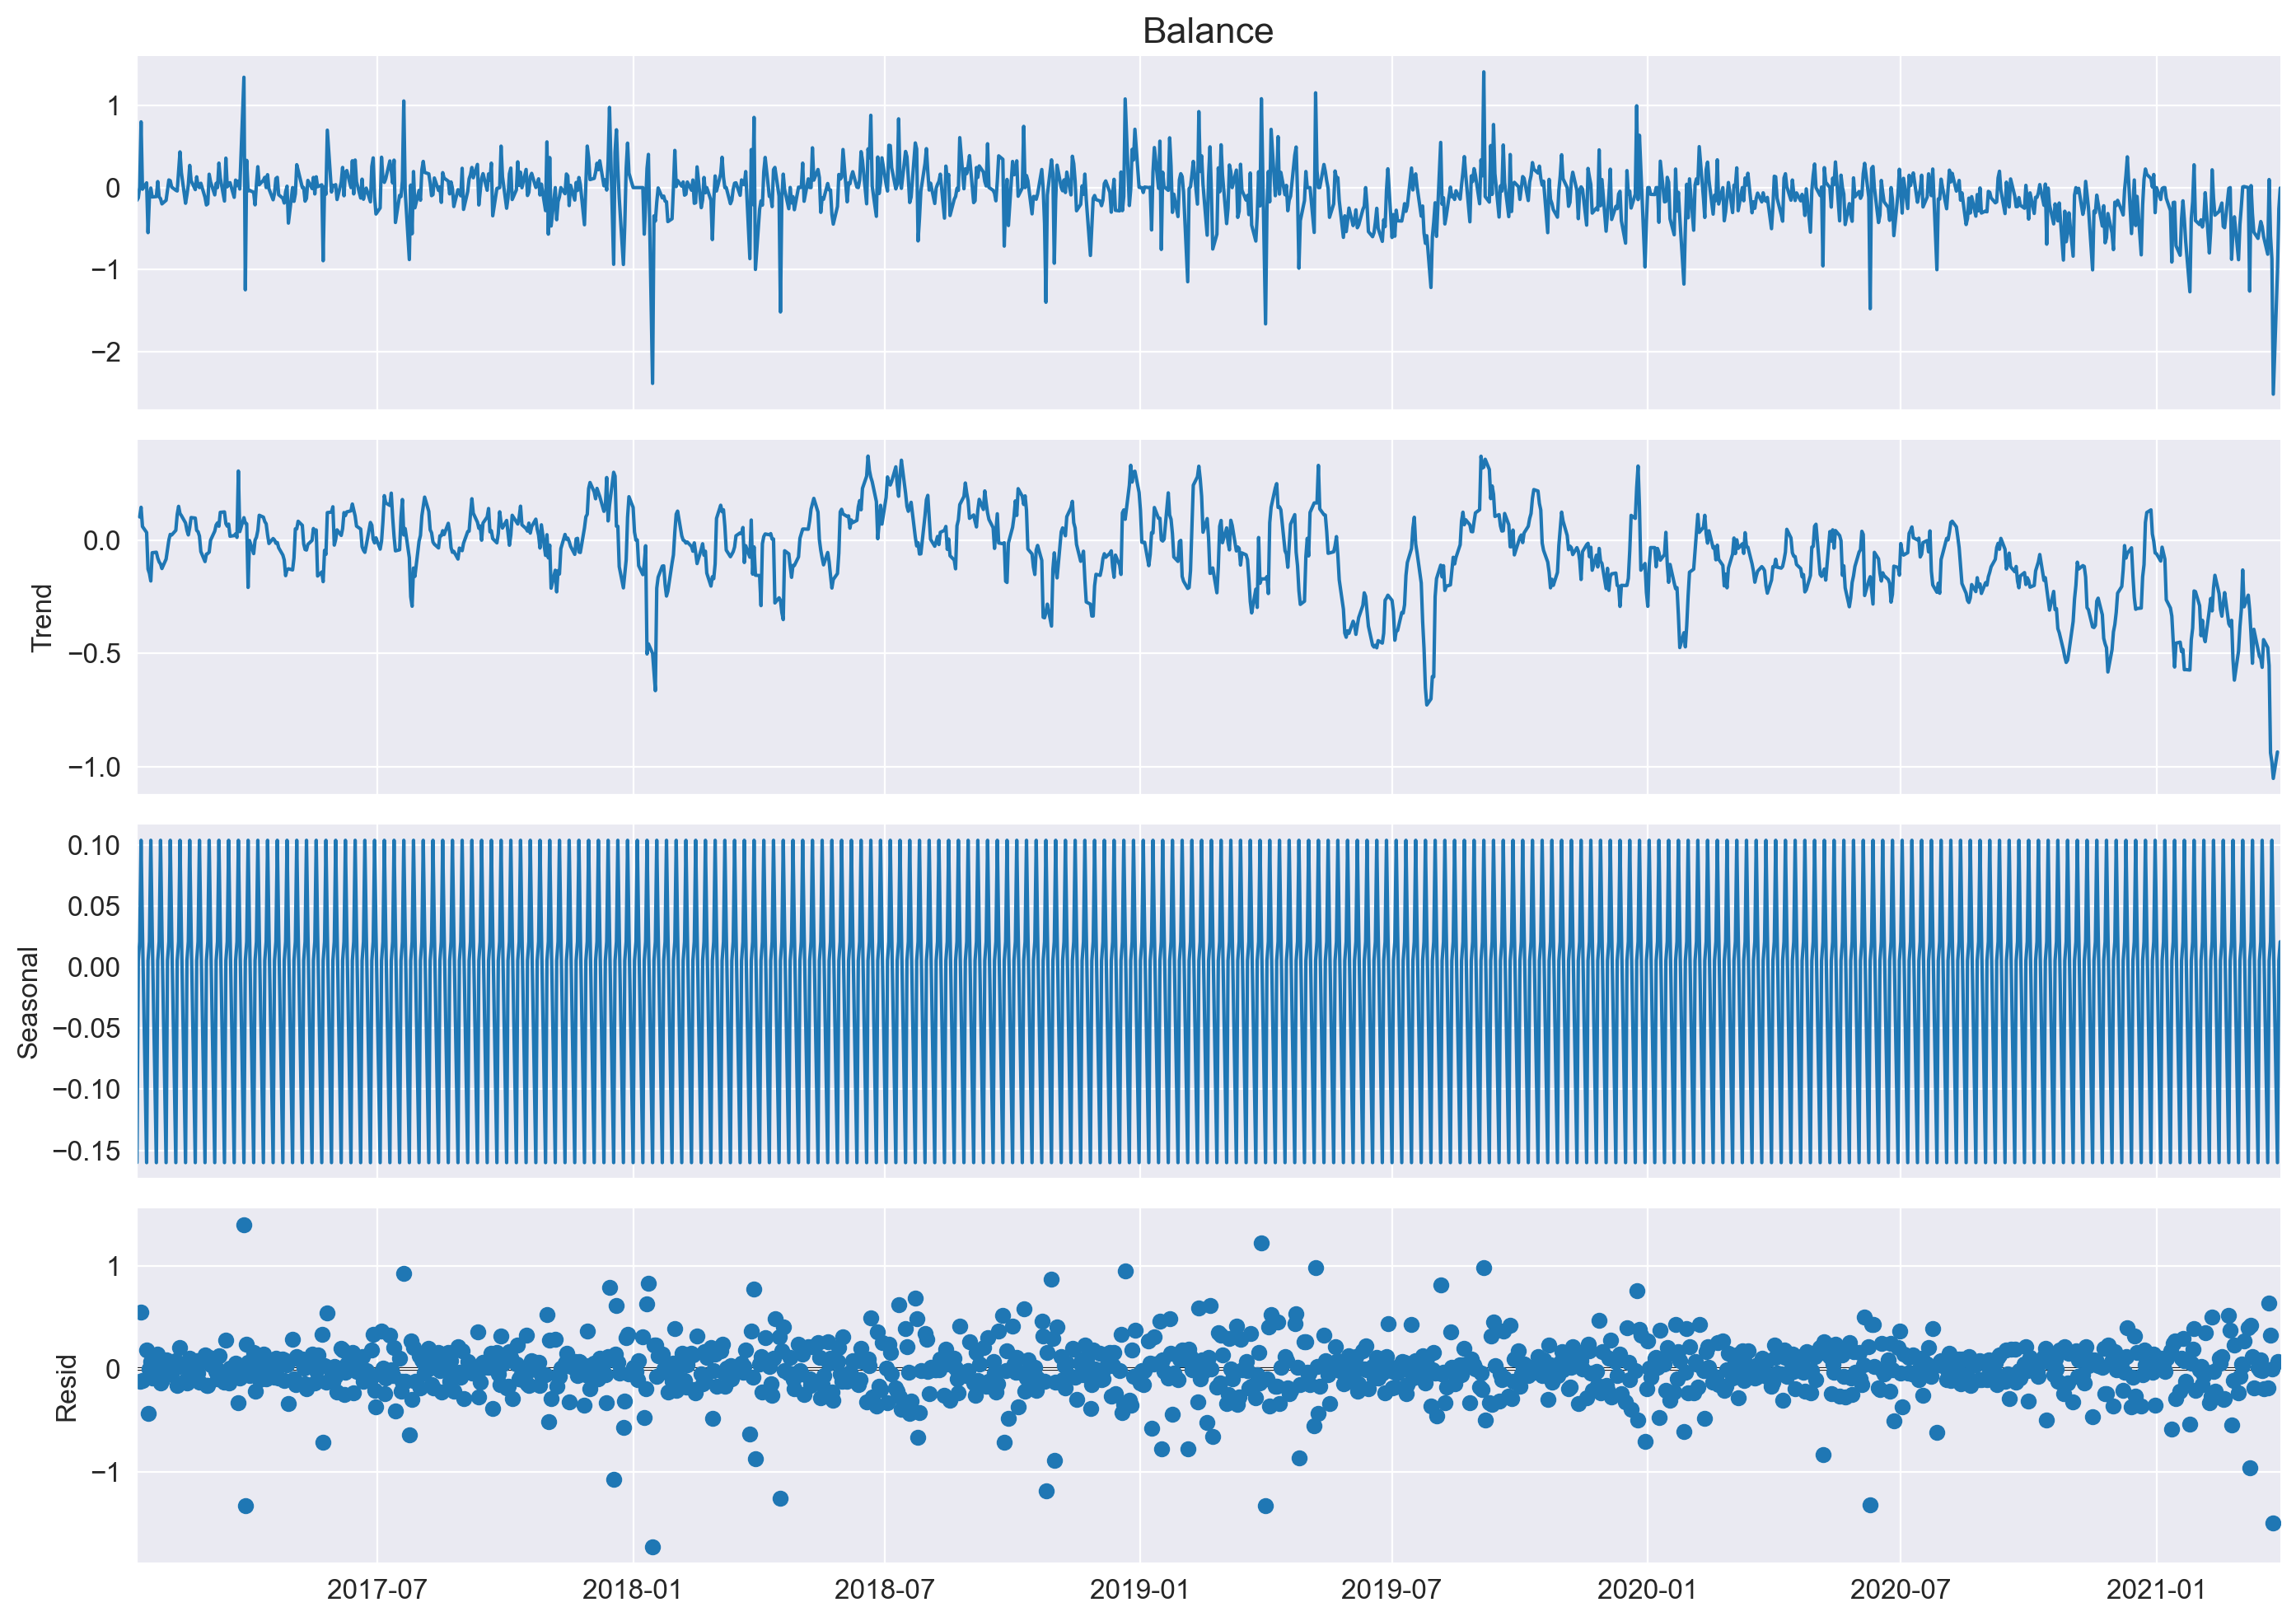

In [19]:
decomposition = seasonal_decompose(series, model="additive", period=5)

fig = decomposition.plot()

fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

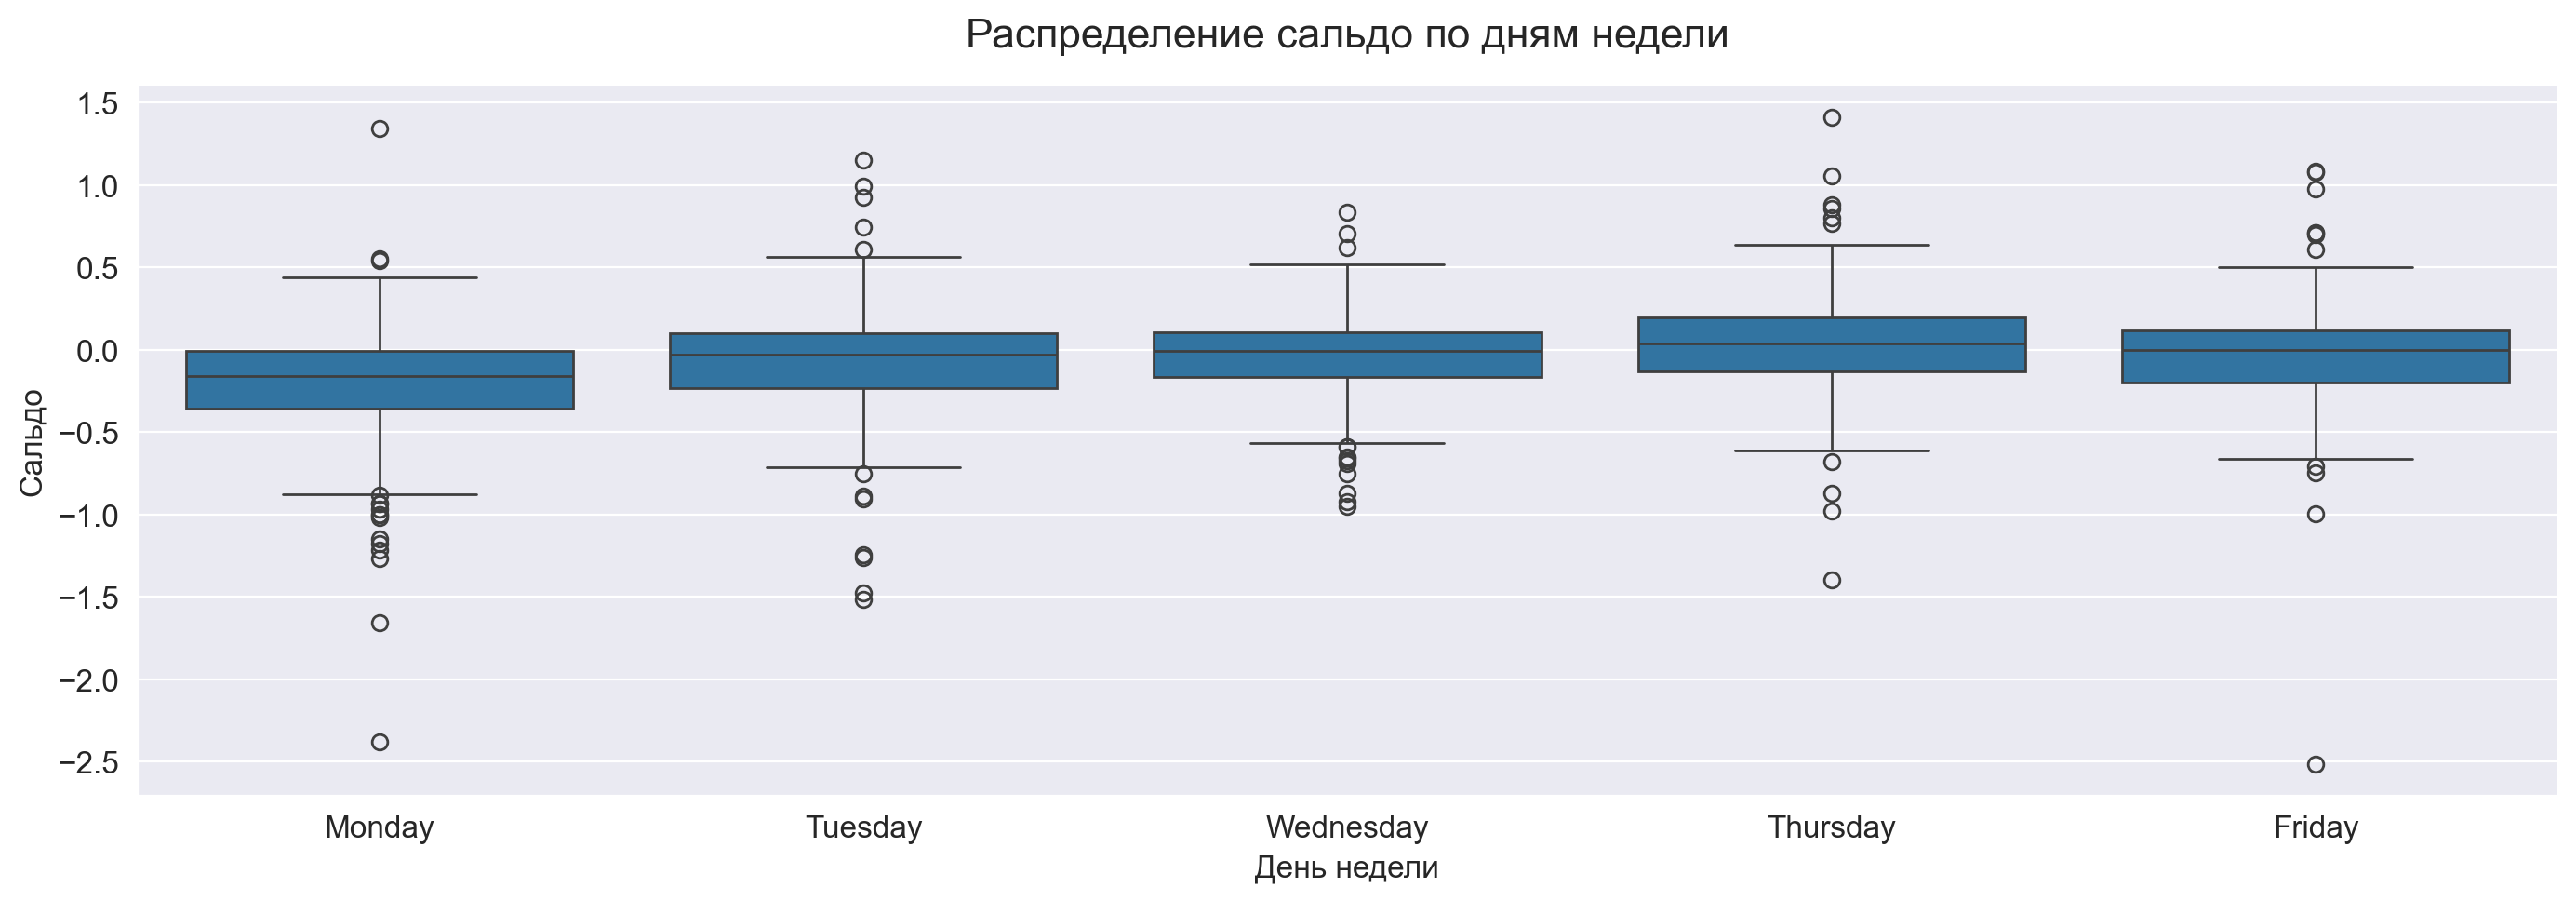

In [20]:
sns.boxplot(data=df, x="DayOfWeek", y="Balance")
plt.title("Распределение сальдо по дням недели", pad=15)
plt.xlabel("День недели")
plt.ylabel("Сальдо")
plt.tight_layout()
plt.show()

## На графиках видно, что сезонность в данных есть. Попробуем недельную сезонность: s = 5; 
## Сезонная компонента выглядит стабильной: D = 0; 
## Из графиков ACF и PACF пики на лагах 5, 10, 15. Попробуем P и Q равными 1

In [21]:
sarima_model, sarima_result, sarima_metrics = run_sarima(y_train=y_train, y_test=y_test, order=(1, 0, 1), seasonal_order=(1, 0, 1, 5))

sarima_metrics

{'MAE': 0.21560511864197157}

## При других комбинациях параметров получается хуже качество.
## Модель стала точнее

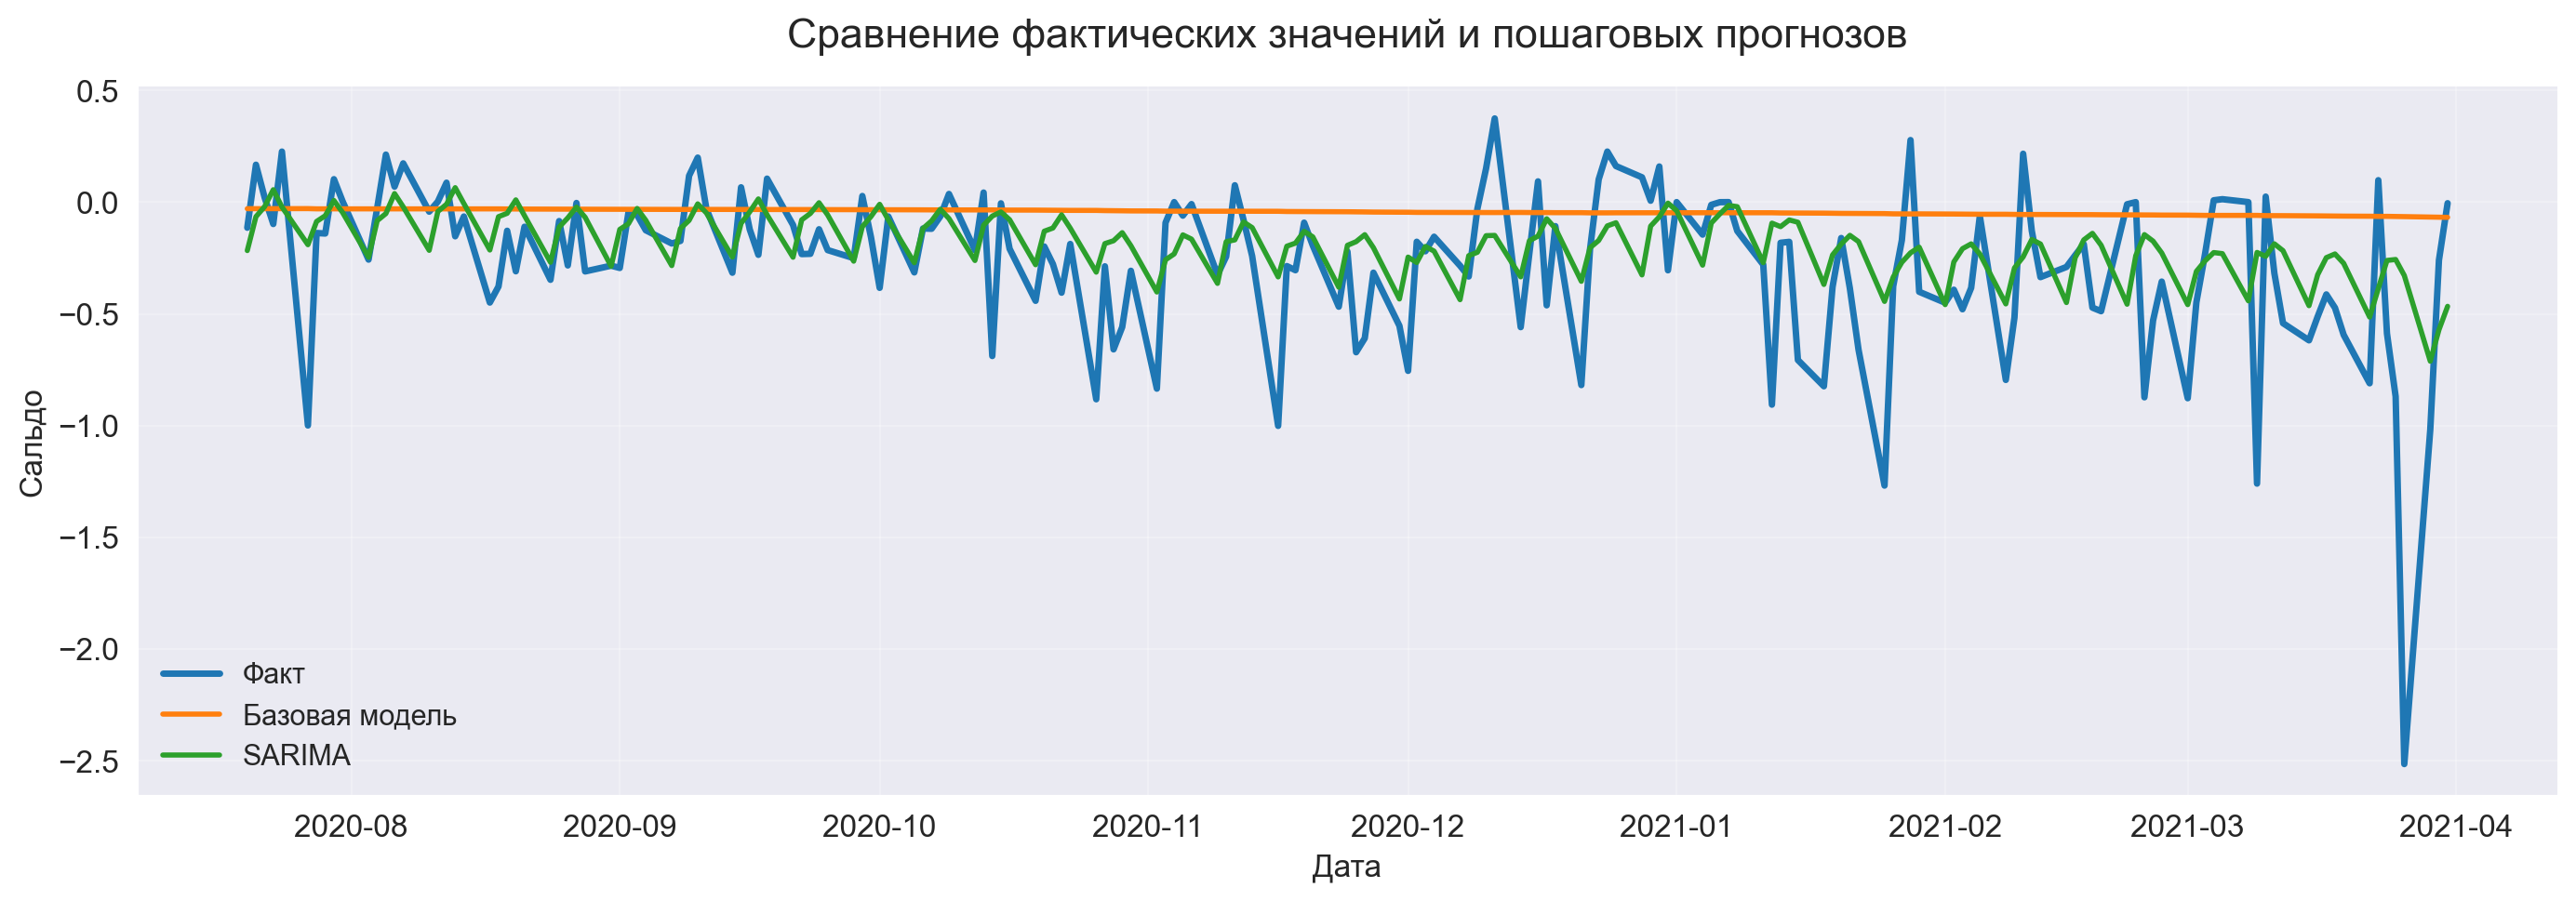

In [22]:
comparison_df = pd.DataFrame({
    "Факт": y_test.values,
    "Базовая модель": baseline_result["Predicted"].values,
    "SARIMA": sarima_result["Predicted"].values
}, index=y_test.index)

sns.lineplot(x=comparison_df.index, y=comparison_df["Факт"], label="Факт", linewidth=2.5)
sns.lineplot(x=comparison_df.index, y=comparison_df["Базовая модель"], label="Базовая модель", linewidth=2)
sns.lineplot(x=comparison_df.index, y=comparison_df["SARIMA"], label="SARIMA", linewidth=2)
plt.title("Сравнение фактических значений и пошаговых прогнозов", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Модель SARIMA смогла выявить и воспроизвести сезонную компоненту временного ряда, что подтверждает наличие регулярной недельной структуры данных.

## Однако модель по-прежнему испытывает трудности при прогнозировании резких изменений и экстремальных значений ряда. Это может свидетельствовать о наличии сложных нелинейных зависимостей, которые плохо описываются линейными статистическими моделями.

## Полученные результаты обосновывают дальнейший переход к моделям машинного обучения с расширенным набором признаков.

# ML модели
### Были проверены две ансамблевые модели: случайный лес и Catboost (отличный отечественный аналог недружественным решениям)
### Для подбора гиперпараметров использовалась Optuna

In [23]:
# Генерация признаков
ml_data = create_features(df=df, target_col="Balance")

X, y, dates, feature_cols = get_features_target(ml_data, target_col="Balance")

print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество признаков: {len(feature_cols)}")

Размер матрицы признаков: (1074, 74)
Количество признаков: 74


In [24]:
tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(X))

train_idx, test_idx = splits[-1]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

test_dates = dates.iloc[test_idx]

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (895, 74)
Размер тестовой выборки: (179, 74)


## Случайный лес

In [25]:
rf_best_params, rf_best_score, rf_study = tune_random_forest(X=X_train, y=y_train, n_trials=30, n_splits=5)

print("Лучшие параметры случайного леса:")
print(rf_best_params)
print("\nЛучшее значение MAE на проверке:")
print(rf_best_score)

[I 2026-05-31 17:13:44,908] A new study created in memory with name: no-name-d3e87800-d900-4a1b-b98b-454d1c36e6a5
[I 2026-05-31 17:13:46,377] Trial 0 finished with value: 0.23656483304609816 and parameters: {'n_estimators': 364, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.23656483304609816.
[I 2026-05-31 17:13:47,471] Trial 1 finished with value: 0.24121631311039224 and parameters: {'n_estimators': 281, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.23656483304609816.
[I 2026-05-31 17:13:49,213] Trial 2 finished with value: 0.24131137181946696 and parameters: {'n_estimators': 451, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.23656483304609816.
[I 2026-05-31 17:13:51,222] Trial 3 finished with value: 0.24163843442685703 and parameters: {'n_estimators': 444, 'max_depth':

Лучшие параметры случайного леса:
{'n_estimators': 164, 'max_depth': 16, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'log2'}

Лучшее значение MAE на проверке:
0.23351579240912104


In [26]:
# Обучение модели с лучшими параметрами
rf_model, rf_result, rf_metrics = run_random_forest(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, params=rf_best_params)

rf_result.index = test_dates.values

print(rf_metrics)

{'MAE': 0.21831284280575675}


### Случайный лес с подобранными гиперпараметрами показал MAE = 0.218, что лучше бейзлайна (0.281) и ARIMA (0.232), и вплотную приближается к результату SARIMA (0.216).
### Оптимальные параметры тяготеют к ограниченному числу признаков на каждом разбиении (max_features = log2) и крупным листьям (min_samples_leaf = 9), что помогает избежать переобучения на шуме временного ряда.

## CatBoost

In [27]:
cat_best_params, cat_best_score, cat_study = tune_catboost(X=X_train, y=y_train, n_trials=30, n_splits=5)

print("Лучшие параметры CatBoost:")
print(cat_best_params)
print("\nЛучшее значение MAE на проверке:")
print(cat_best_score)

[I 2026-05-31 17:14:18,592] A new study created in memory with name: no-name-8e22f86b-d18a-4612-96f0-ade92d88dc75
[I 2026-05-31 17:14:19,516] Trial 0 finished with value: 0.24698020981003815 and parameters: {'iterations': 215, 'depth': 4, 'learning_rate': 0.18376835900805683, 'l2_leaf_reg': 5.864021763760802, 'random_strength': 3.1043142510267723, 'bagging_temperature': 1.3038625846738423}. Best is trial 0 with value: 0.24698020981003815.
[I 2026-05-31 17:14:21,905] Trial 1 finished with value: 0.2388502016500748 and parameters: {'iterations': 444, 'depth': 5, 'learning_rate': 0.06040370322801773, 'l2_leaf_reg': 2.5216088734609734, 'random_strength': 0.7618281076628475, 'bagging_temperature': 4.754822705027667}. Best is trial 1 with value: 0.2388502016500748.
[I 2026-05-31 17:14:23,720] Trial 2 finished with value: 0.2403944217131176 and parameters: {'iterations': 481, 'depth': 4, 'learning_rate': 0.07767113658181433, 'l2_leaf_reg': 7.840209970276635, 'random_strength': 4.4105349776972

Лучшие параметры CatBoost:
{'iterations': 730, 'depth': 3, 'learning_rate': 0.0215570373442132, 'l2_leaf_reg': 6.721454983604491, 'random_strength': 2.3160753018454447, 'bagging_temperature': 3.3513930938025176}

Лучшее значение MAE на проверке:
0.23046249989801412


In [28]:
# Обучение модели с лучшими параметрами
cat_model, cat_result, cat_metrics = run_catboost(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, params=cat_best_params)

cat_result.index = test_dates.values

print(cat_metrics)

{'MAE': 0.21356063907530465}


### CatBoost с подобранными гиперпараметрами показал MAE = 0.214 — лучший результат среди ML-моделей, который также превзошёл SARIMA (0.216) и Random Forest (0.218).
### Оба ML-метода значительно превосходят бейзлайн (0.281) и ARIMA (0.232).

## Сравнение прогнозов

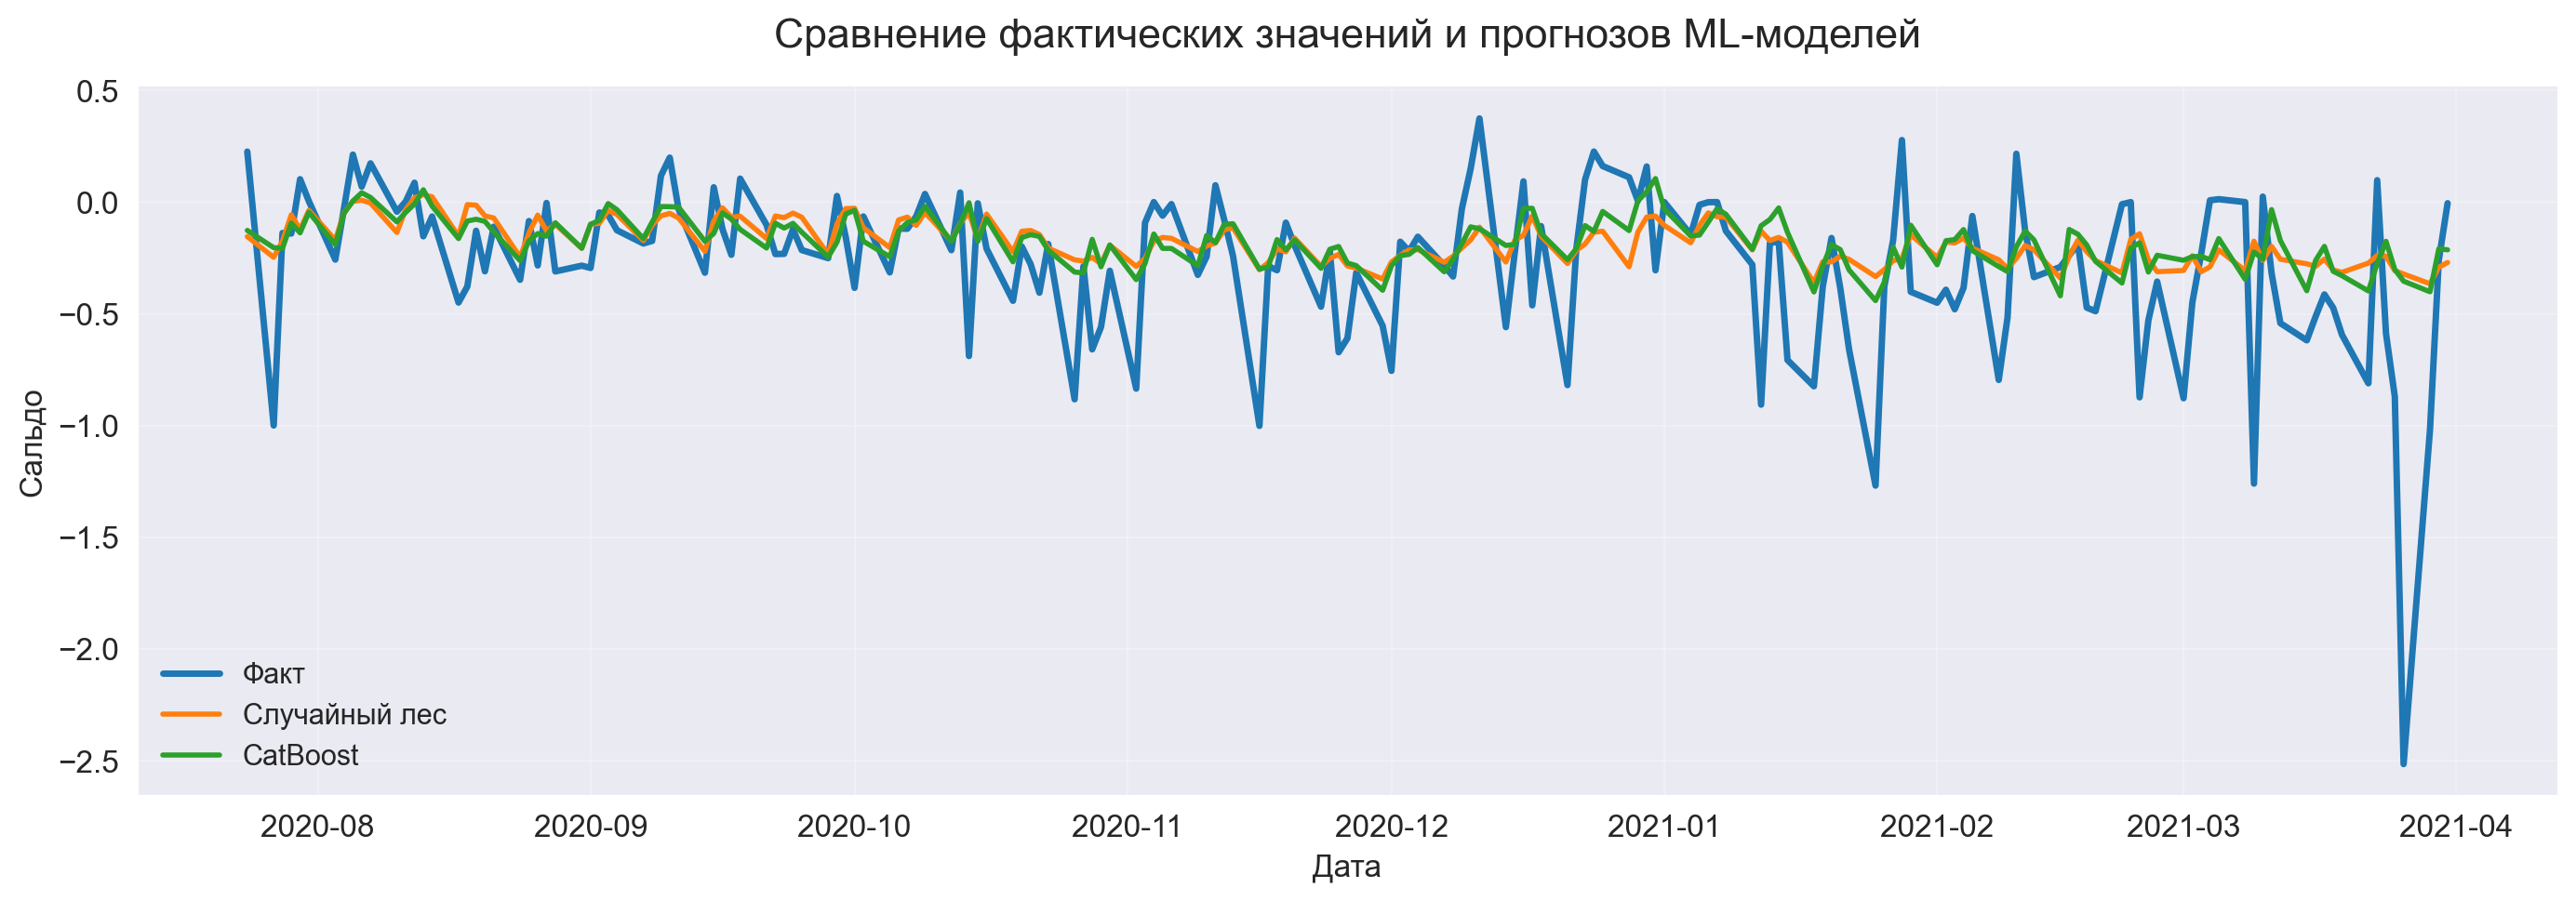

In [29]:
ml_comparison_df = pd.DataFrame({"Факт": y_test.values, "Случайный лес": rf_result["Predicted"].values, "CatBoost": cat_result["Predicted"].values}, index=ml_data.iloc[test_idx]["Date"])

sns.lineplot(x=ml_comparison_df.index, y=ml_comparison_df["Факт"], label="Факт", linewidth=2.5)
sns.lineplot(x=ml_comparison_df.index, y=ml_comparison_df["Случайный лес"], label="Случайный лес", linewidth=2)
sns.lineplot(x=ml_comparison_df.index, y=ml_comparison_df["CatBoost"], label="CatBoost", linewidth=2)
plt.title("Сравнение фактических значений и прогнозов ML-моделей", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend(frameon=False)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### ML модели получились лучше бейзлайна, но не лучше SARIMA

## Важность признаков (для модели CatBoost)

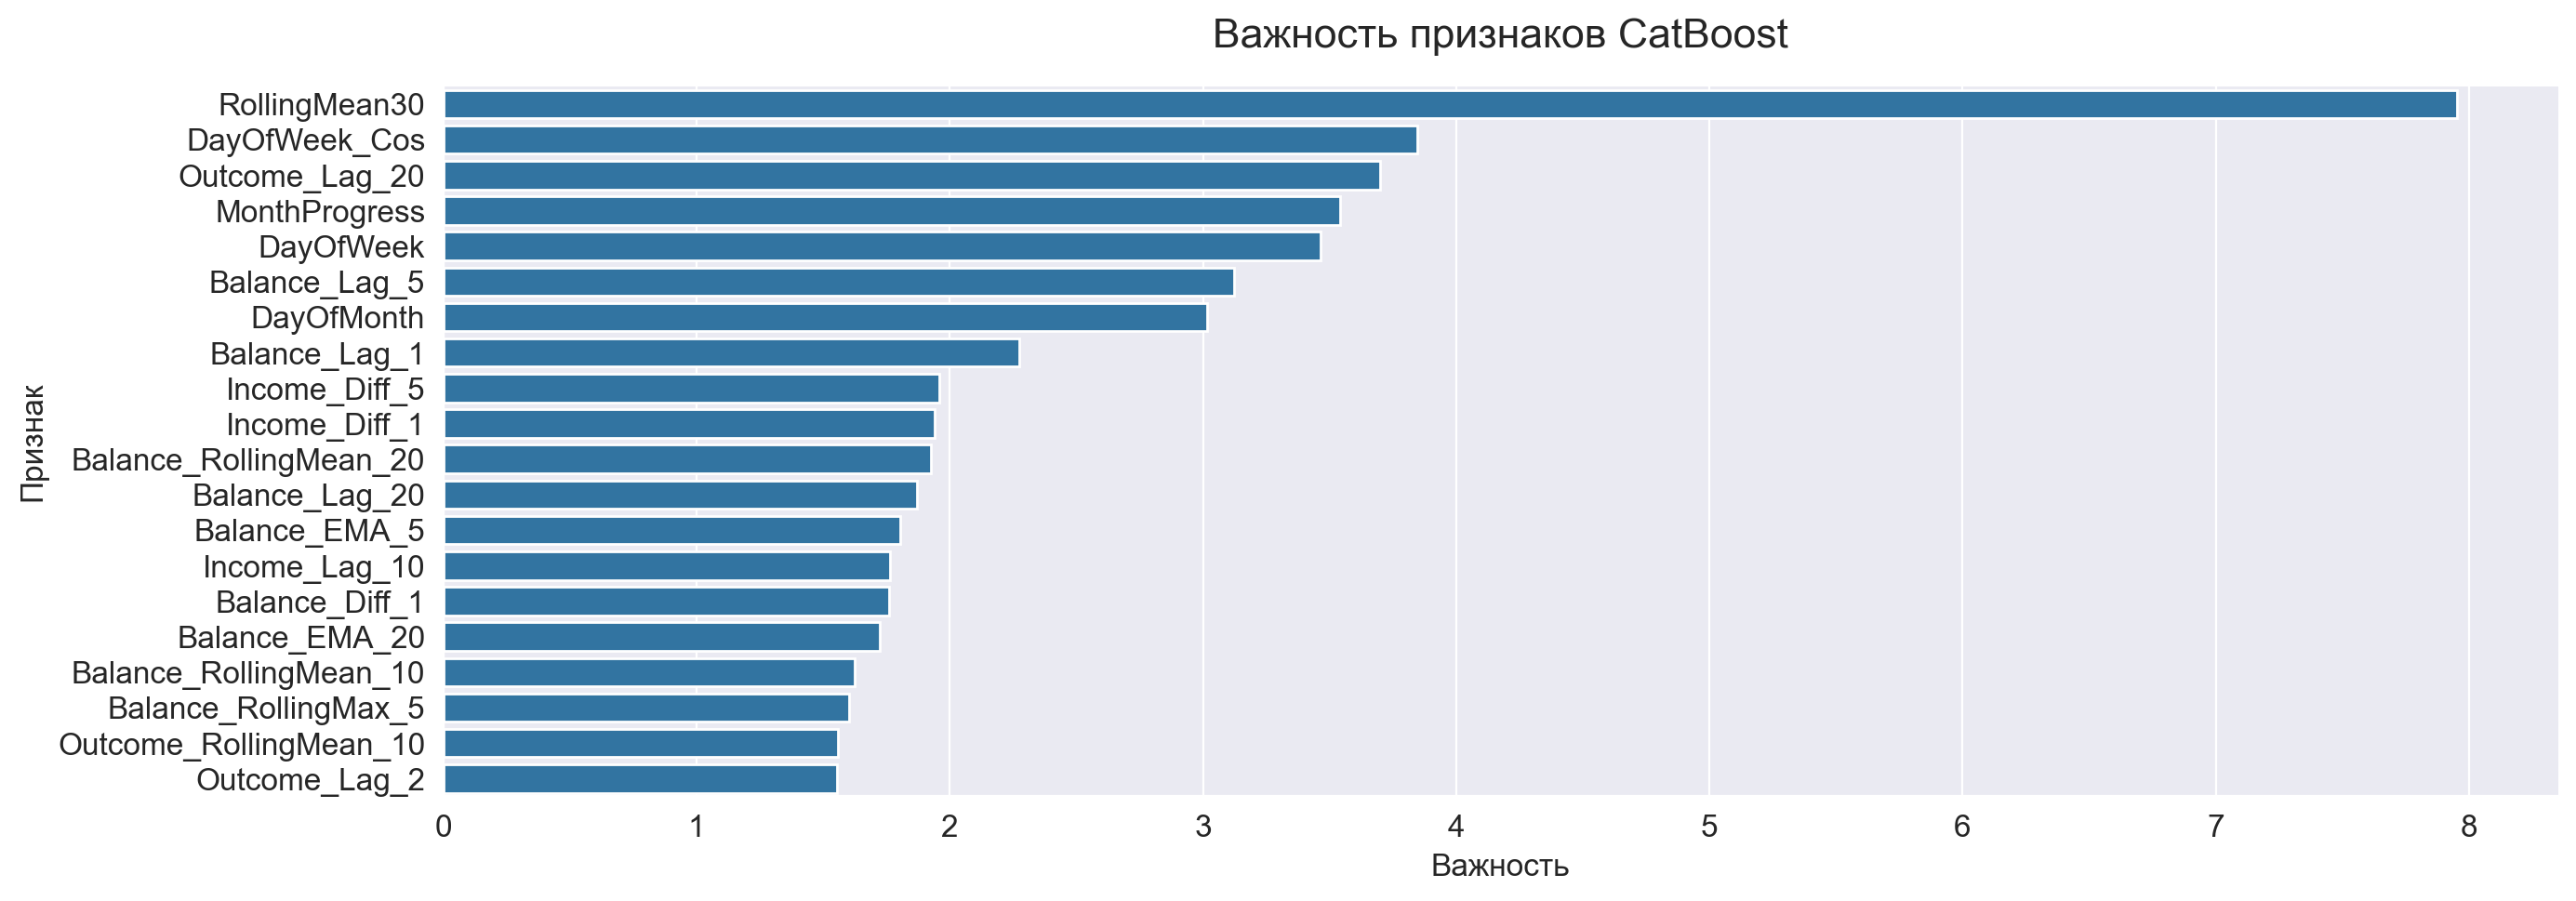

In [30]:
cat_importance_df = get_feature_importance(model=cat_model, feature_names=X_train.columns)

sns.barplot(data=cat_importance_df.head(20), x="Importance", y="Feature")
plt.title("Важность признаков CatBoost", pad=15)
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

### Наиболее значимыми признаками по встроенной важности CatBoost являются ближайшие лаги сальдо (Lag_1, Lag_2, Lag_3) и скользящие средние, что подтверждает высокую инерционность временного ряда.
### Календарные признаки (день недели, месяц) также входят в число значимых, отражая выявленные ранее сезонные паттерны.

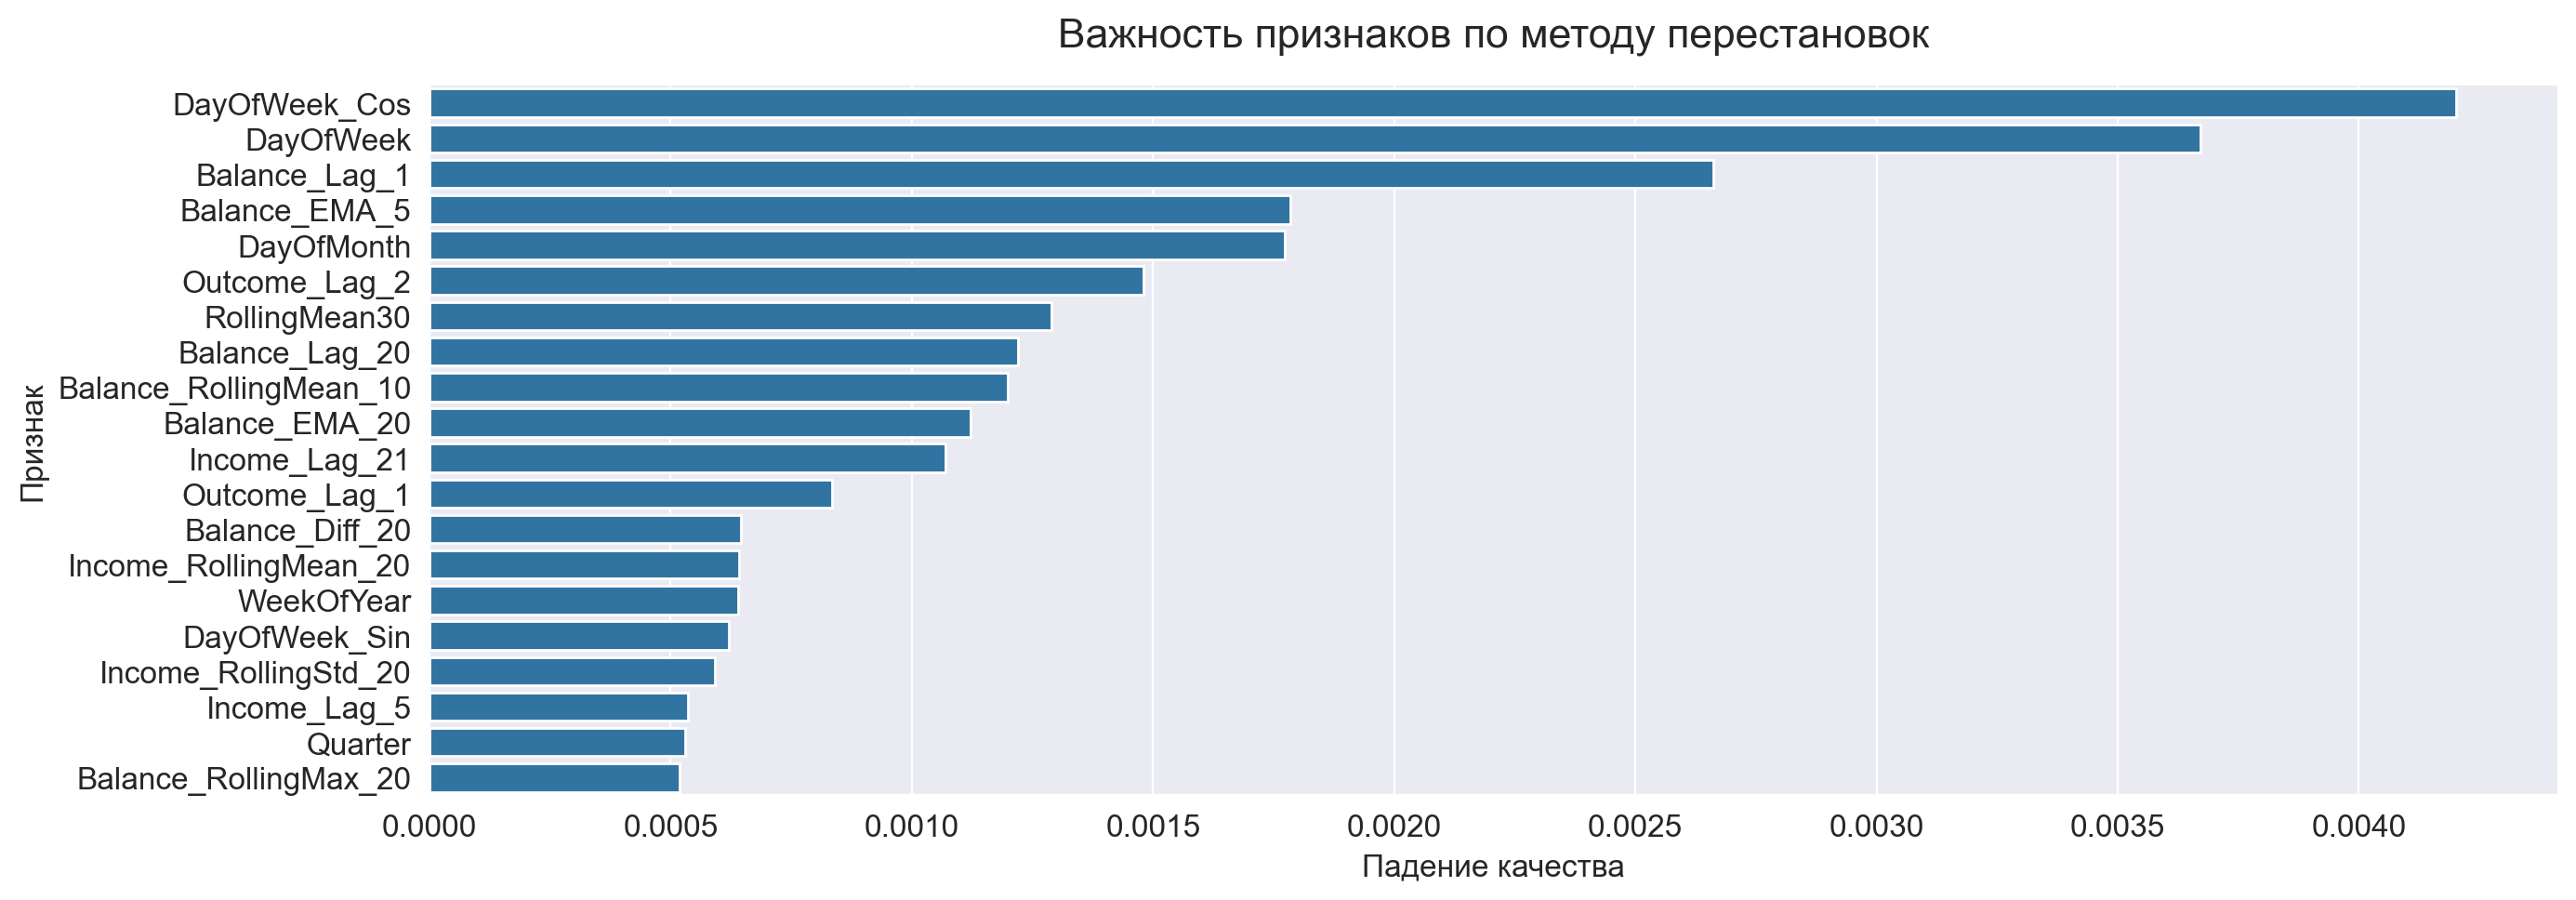

In [31]:
perm_importance_df = get_permutation_importance(model=cat_model, X=X_test, y=y_test, n_repeats=20)

sns.barplot(data=perm_importance_df.head(20), x="Importance", y="Feature")
plt.title("Важность признаков по методу перестановок", pad=15)
plt.xlabel("Падение качества")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

### Метод перестановок подтверждает приоритет лаговых признаков: перемешивание Lag_1 приводит к наибольшему падению качества модели.
### В отличие от встроенной важности, permutation importance учитывает реальный вклад признаков с учётом взаимодействий и даёт более надёжную оценку их ценности для прогноза.

# Макрофакторы

## Исследованы курс рубль-доллар и ключевая ставка ЦБ

In [32]:
# Курс Рубль-Доллар
rub_usd = load_data("RUB_USD.xlsx", sheet_name="RC")

In [33]:
key_rate = save_key_rate_to_excel(
    start_date="09.01.2017",
    end_date="31.03.2021",
    file_name="KEY_RATE.xlsx",
    folder="data"
)

key_rate["KeyRate"] = key_rate["KeyRate"] / 100

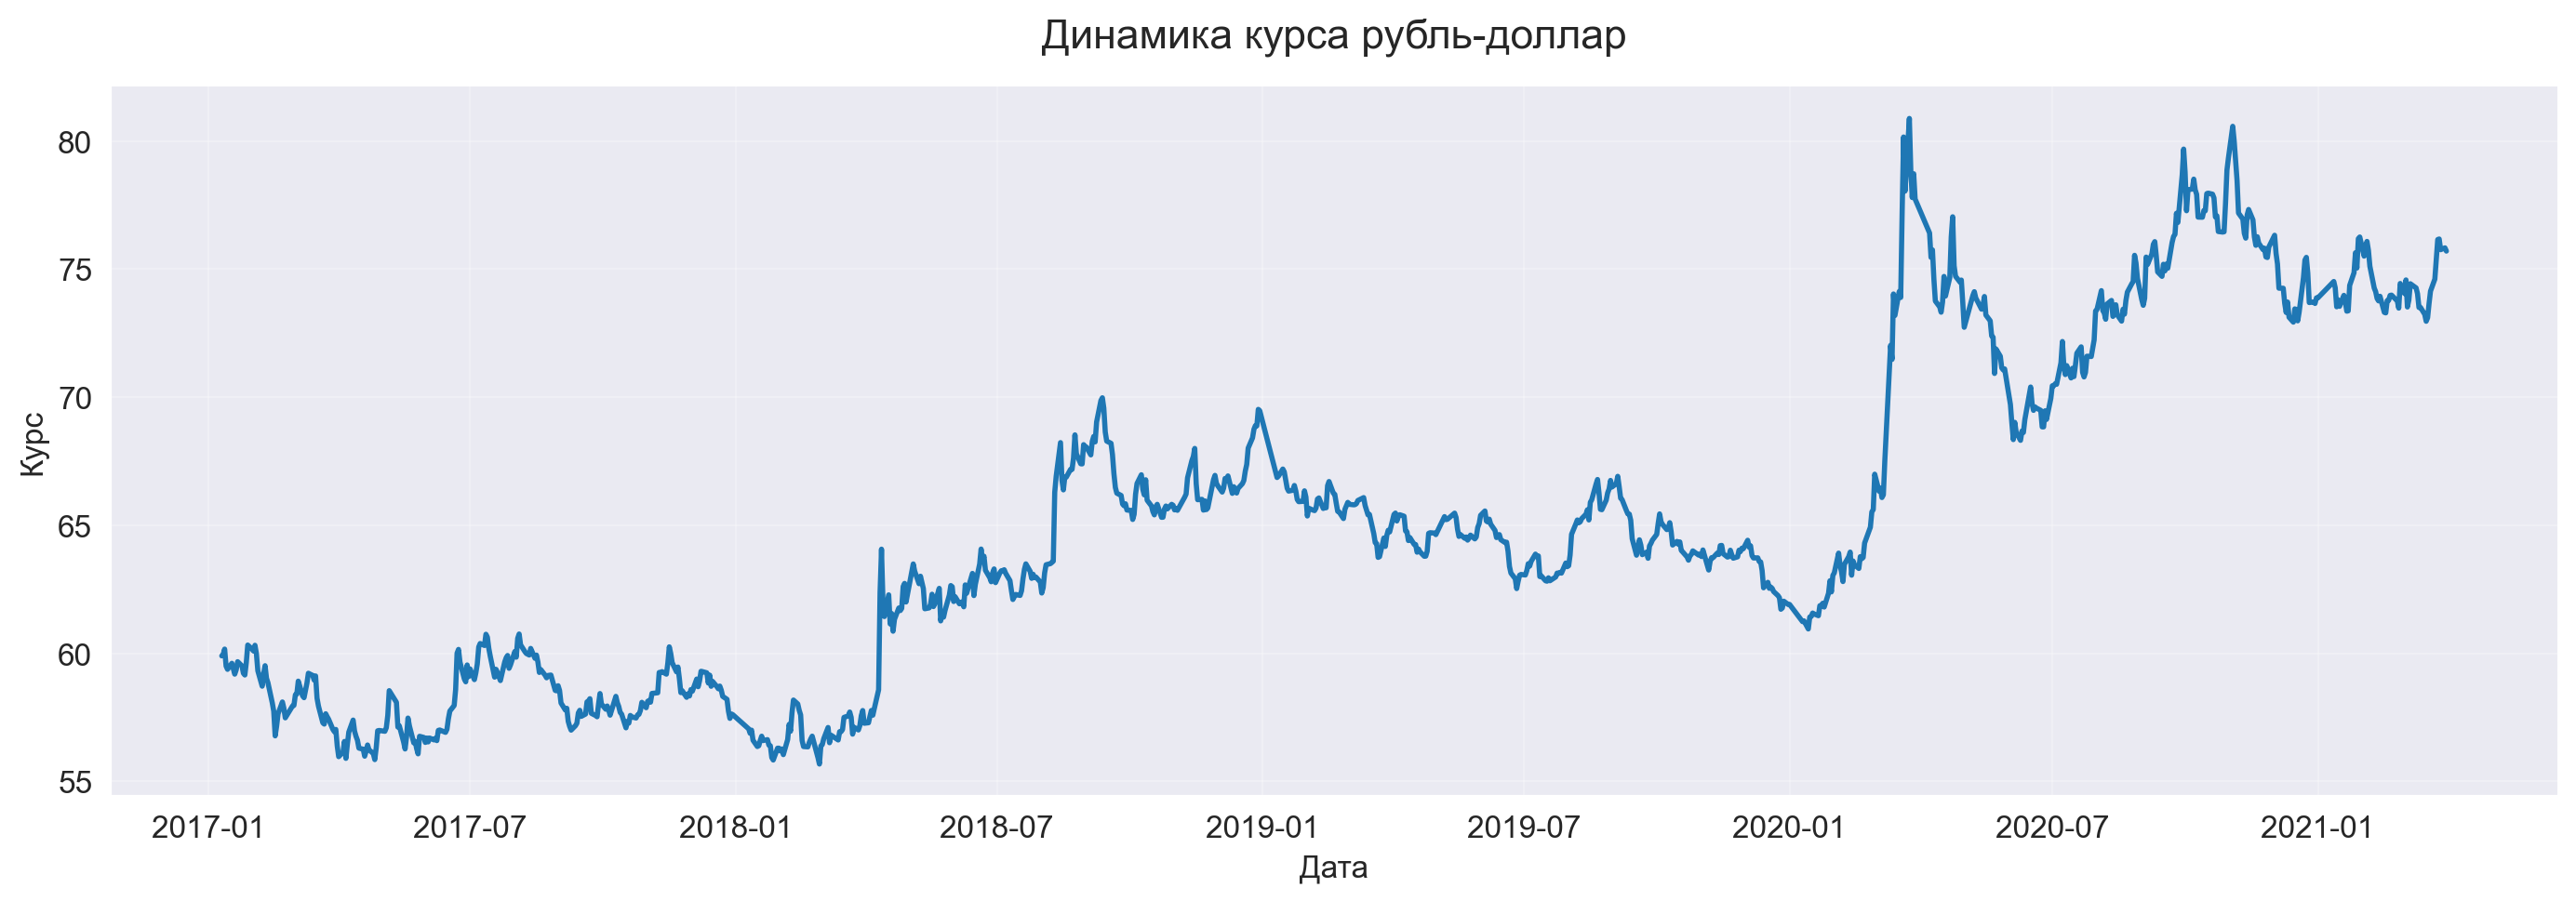

In [34]:
sns.lineplot(data=rub_usd, x="data", y="curs", linewidth=2)
plt.title("Динамика курса рубль-доллар", pad=15)
plt.xlabel("Дата")
plt.ylabel("Курс")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

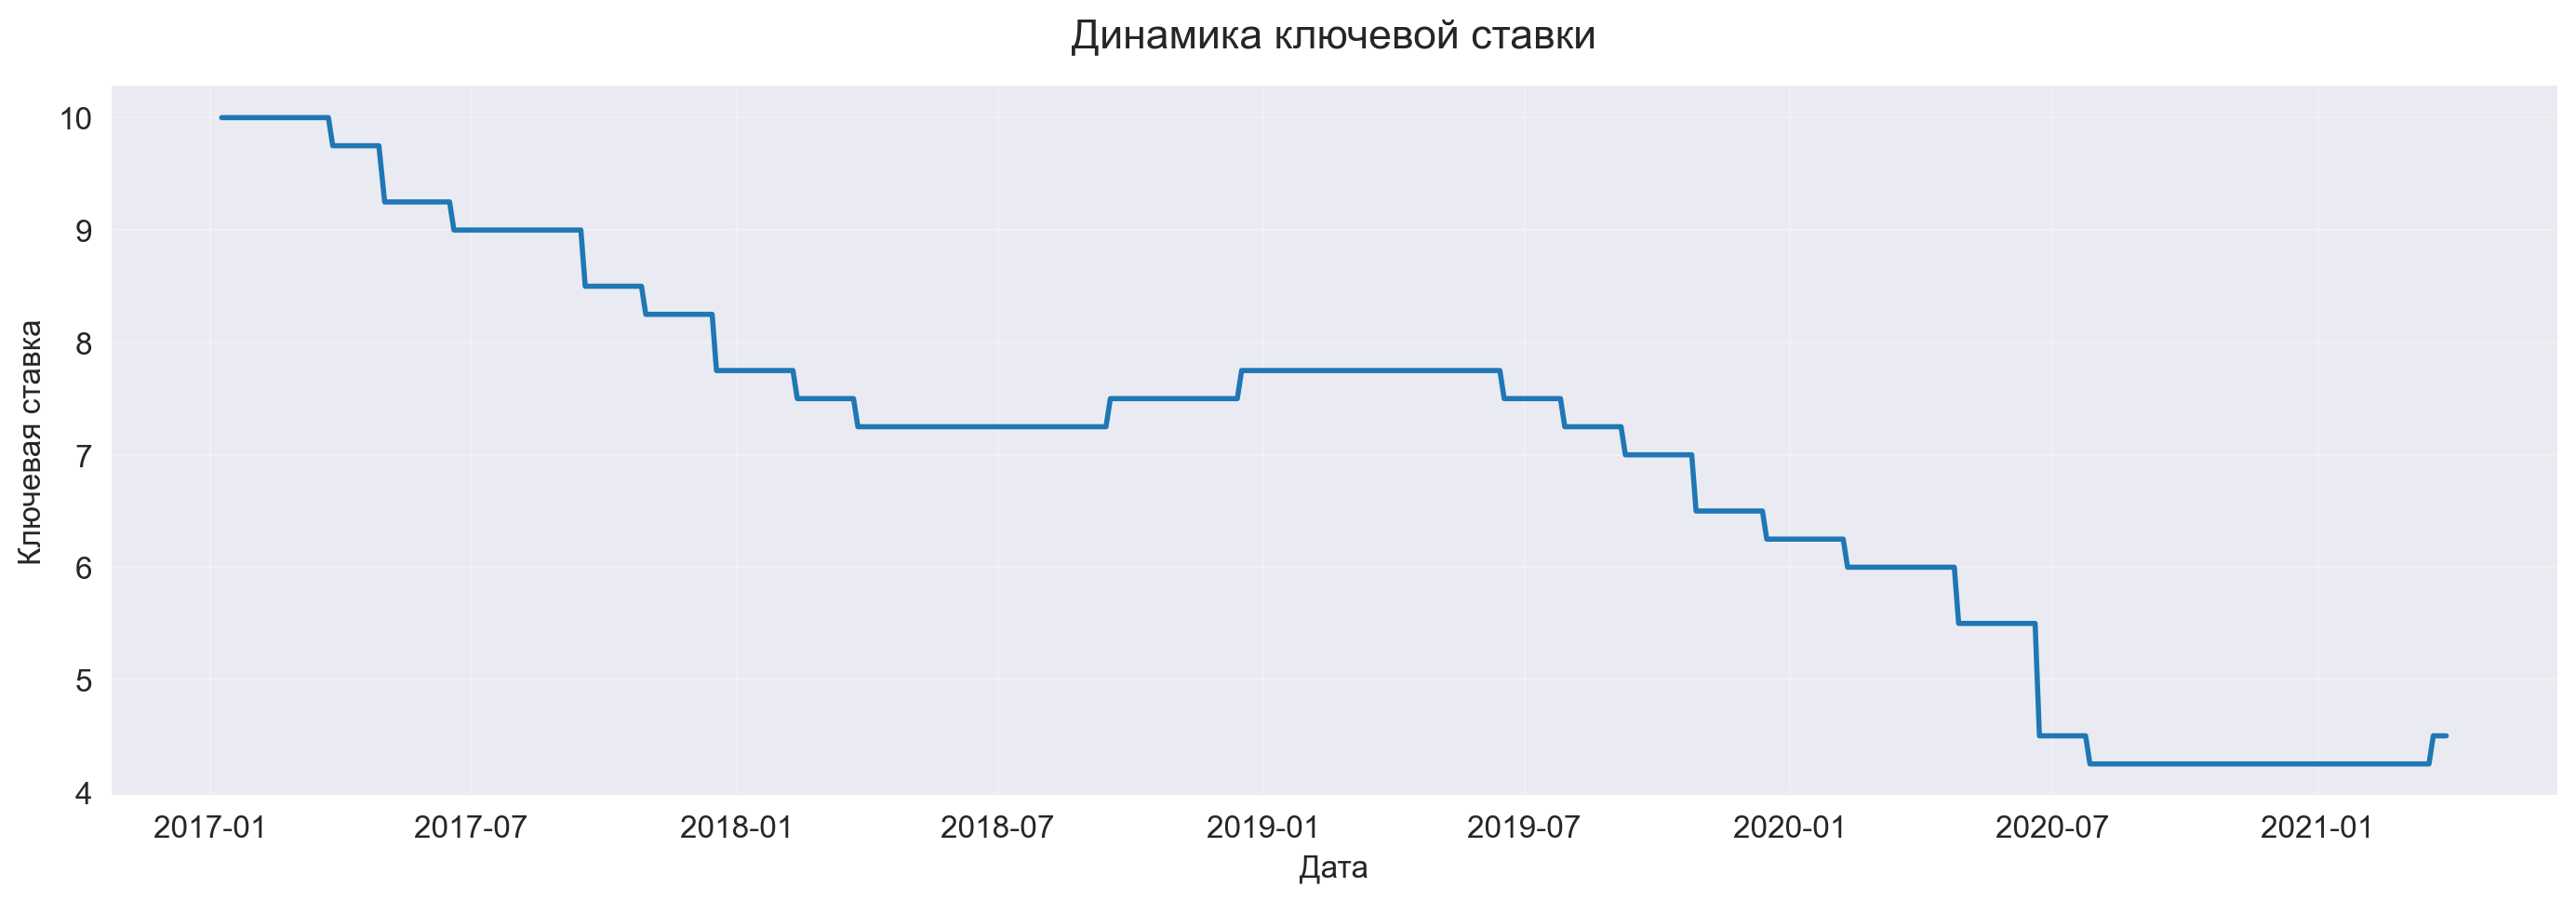

In [35]:
sns.lineplot(data=key_rate, x="Date", y="KeyRate", linewidth=2)
plt.title("Динамика ключевой ставки", pad=15)
plt.xlabel("Дата")
plt.ylabel("Ключевая ставка")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Оба макропоказателя имеют долгосрочный тренд, поэтому в модель включаются их лаговые значения, а не уровни, чтобы избежать ложных корреляций.

In [36]:
ml_data_macro = create_features(df=df, rub_usd=rub_usd, key_rate=key_rate, target_col="Balance")

X_macro, y_macro, dates_macro, feature_cols_macro = get_features_target(data=ml_data_macro, target_col="Balance")

In [37]:
# Матрица корреляций таргета от новых макрофичей
macro_cols = [
    "Balance",
    "USD_RUB_Lag_1",
    "USD_RUB_Lag_5",
    "USD_RUB_Lag_10",
    "USD_RUB_Change_1",
    "USD_RUB_Change_5",
    "KeyRate_Lag_1",
    "KeyRate_Lag_5",
    "KeyRate_Lag_20",
    "KeyRate_Change_1",
    "KeyRate_Change_5",
    "KeyRate_Change_20"
]

corr_matrix = ml_data_macro[macro_cols].corr()

corr_matrix

,Balance,USD_RUB_Lag_1,USD_RUB_Lag_5,USD_RUB_Lag_10,USD_RUB_Change_1,USD_RUB_Change_5,KeyRate_Lag_1,KeyRate_Lag_5,KeyRate_Lag_20,KeyRate_Change_1,KeyRate_Change_5,KeyRate_Change_20
Balance,1.000000,-0.208393,-0.209292,-0.219527,0.002329,-0.000240,0.244593,0.246927,0.249453,0.004120,-0.028790,-0.029497
USD_RUB_Lag_1,-0.208393,1.000000,0.984185,0.964011,0.050083,0.120501,-0.852216,-0.856216,-0.870033,0.042482,0.099811,0.179805
USD_RUB_Lag_5,-0.209292,0.984185,1.000000,0.980332,-0.038939,-0.040227,-0.847239,-0.850863,-0.865103,0.041202,0.093362,0.178310
USD_RUB_Lag_10,-0.219527,0.964011,0.980332,1.000000,-0.041063,-0.080856,-0.839791,-0.844050,-0.858912,0.046626,0.102507,0.188910
USD_RUB_Change_1,0.002329,0.050083,-0.038939,-0.041063,1.000000,0.444138,-0.020476,-0.021587,-0.020538,0.002996,0.015806,0.012794
USD_RUB_Change_5,-0.000240,0.120501,-0.040227,-0.080856,0.444138,1.000000,-0.050637,-0.052329,-0.049621,-0.005686,0.031282,0.004840
KeyRate_Lag_1,0.244593,-0.852216,-0.847239,-0.839791,-0.020476,-0.050637,1.000000,0.997849,0.991492,0.000171,0.000391,0.022388
KeyRate_Lag_5,0.246927,-0.856216,-0.850863,-0.844050,-0.021587,-0.052329,0.997849,1.000000,0.993019,-0.032159,-0.057976,-0.004921
KeyRate_Lag_20,0.249453,-0.870033,-0.865103,-0.858912,-0.020538,-0.049621,0.991492,0.993019,1.000000,-0.027360,-0.062323,-0.103916
KeyRate_Change_1,0.004120,0.042482,0.041202,0.046626,0.002996,-0.005686,0.000171,-0.032159,-0.027360,1.000000,0.439003,0.205049


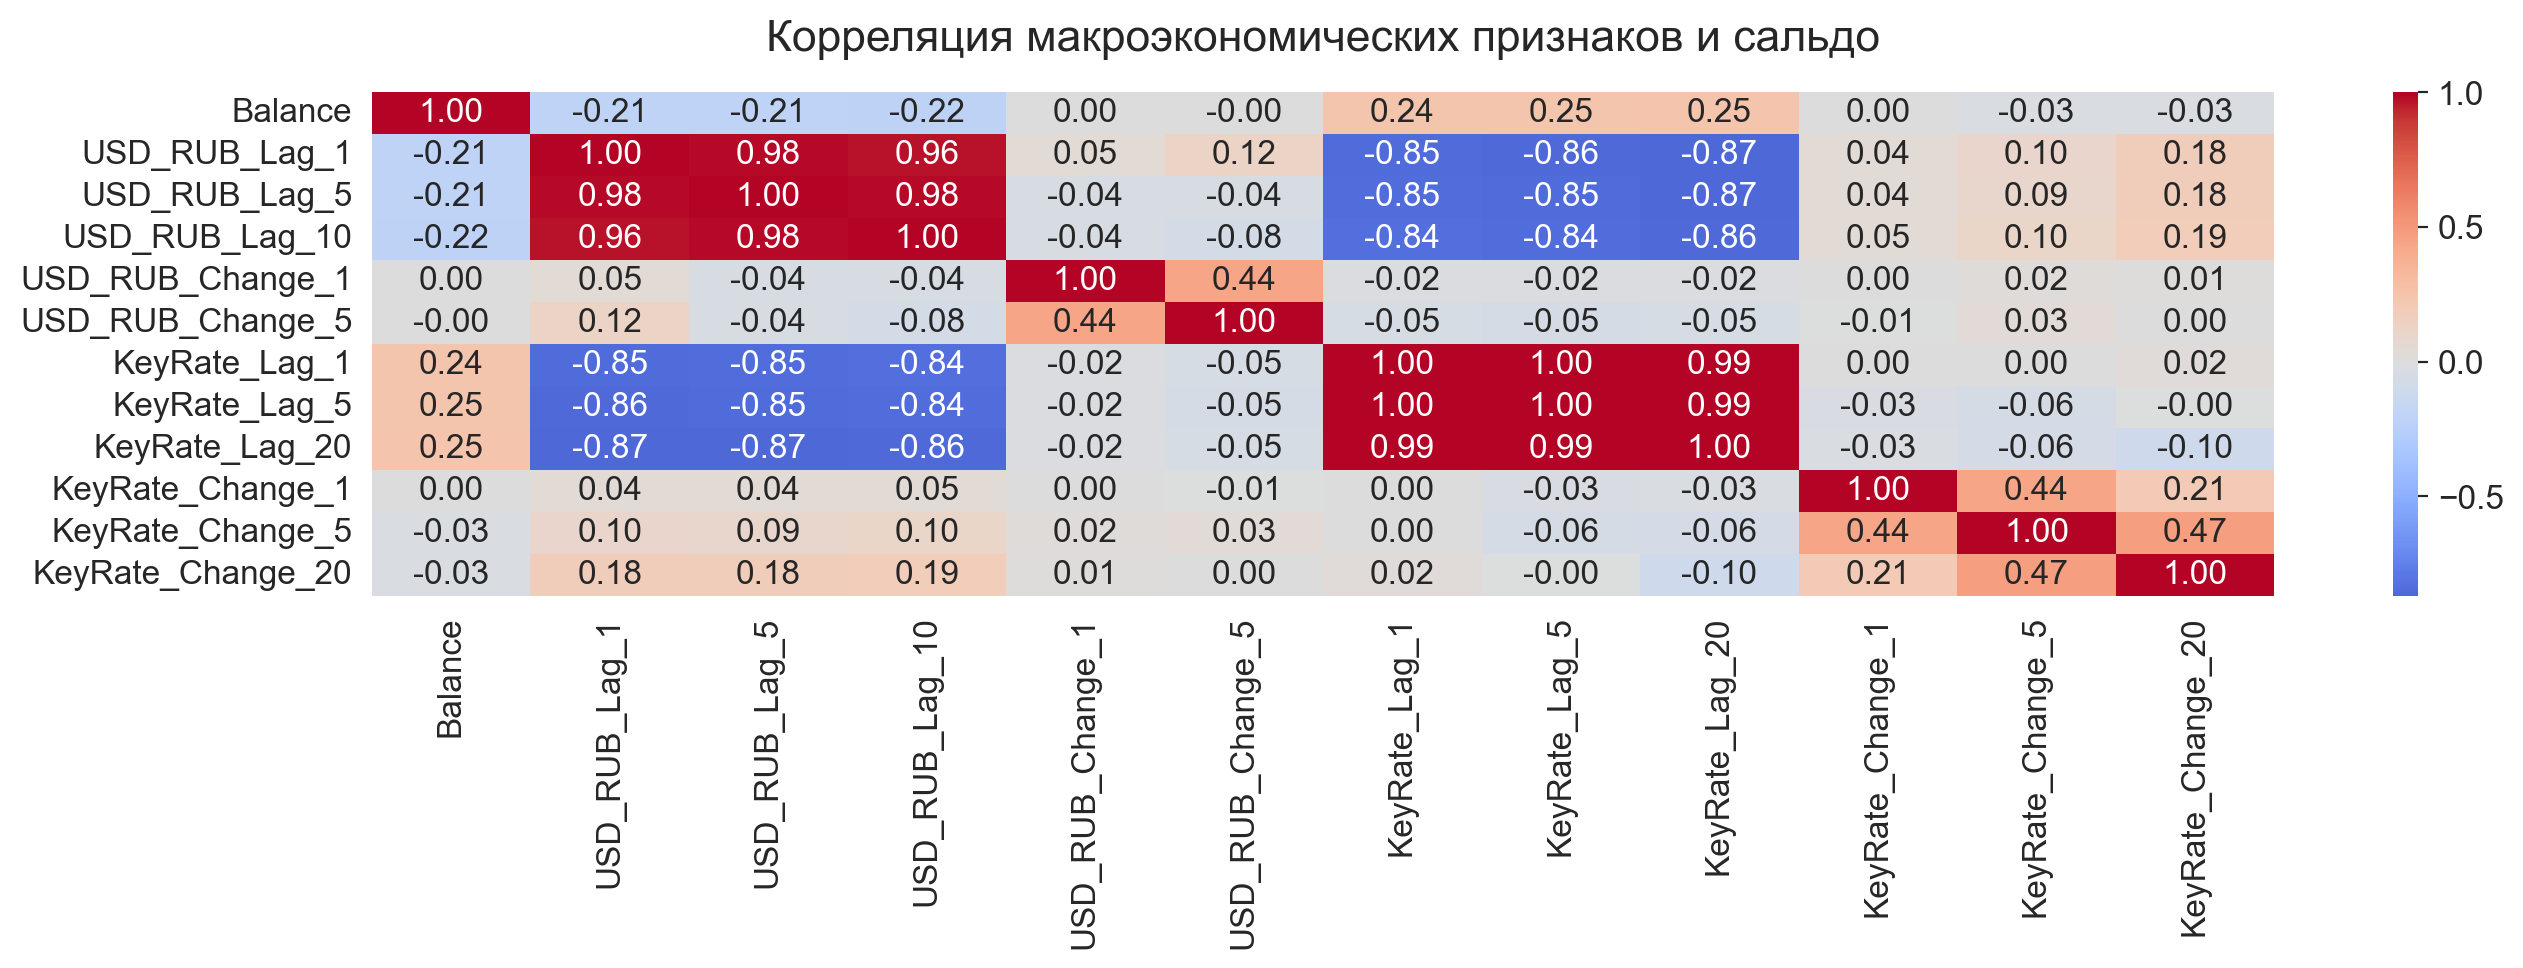

In [38]:
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция макроэкономических признаков и сальдо", pad=15)
plt.tight_layout()
plt.show()

### Лаги ключевой ставки имеют умеренную положительную корреляцию с сальдо (~0.25): более высокая ставка сопровождается незначительным ростом сальдо ликвидности.
### Лаги курса USD/RUB показывают умеренную отрицательную корреляцию (~-0.21): ослабление рубля связано со снижением сальдо.
### Изменения обоих показателей (Change) практически не коррелируют с сальдо — важен уровень, а не направление движения макропеременных.
### Лаги ключевой ставки и курса рубля сильно коррелируют между собой (по модулю ~0.85–0.87), что говорит о мультиколлинеарности: эти признаки несут во многом схожую информацию.

In [39]:
tscv_macro = TimeSeriesSplit(n_splits=5)
splits_macro = list(tscv_macro.split(X_macro))

train_idx_macro, test_idx_macro = splits_macro[-1]

X_train_macro = X_macro.iloc[train_idx_macro]
X_test_macro = X_macro.iloc[test_idx_macro]

y_train_macro = y_macro.iloc[train_idx_macro]
y_test_macro = y_macro.iloc[test_idx_macro]

test_dates_macro = dates_macro.iloc[test_idx_macro]

print(f"Размер обучающей выборки: {X_train_macro.shape}")
print(f"Размер тестовой выборки: {X_test_macro.shape}")

Размер обучающей выборки: (895, 89)
Размер тестовой выборки: (179, 89)


In [40]:
cat_best_params_macro, cat_best_score_macro, cat_study_macro = tune_catboost(X=X_train_macro, y=y_train_macro, n_trials=30, n_splits=5)

print("Лучшие параметры CatBoost:")
print(cat_best_params_macro)
print("\nЛучшее значение MAE на проверке:")
print(cat_best_score_macro)

[I 2026-05-31 17:15:47,424] A new study created in memory with name: no-name-12b8594d-1a10-4b01-b8fe-f04b770fc8b0
[I 2026-05-31 17:15:50,191] Trial 0 finished with value: 0.23890481168404026 and parameters: {'iterations': 348, 'depth': 6, 'learning_rate': 0.03413301447483917, 'l2_leaf_reg': 7.050491350444531, 'random_strength': 2.597563127088472, 'bagging_temperature': 1.5187815399605842}. Best is trial 0 with value: 0.23890481168404026.
[I 2026-05-31 17:15:52,827] Trial 1 finished with value: 0.2603995613134097 and parameters: {'iterations': 712, 'depth': 4, 'learning_rate': 0.1497002484427273, 'l2_leaf_reg': 5.119837203722288, 'random_strength': 1.9045501034414092, 'bagging_temperature': 4.75956768722174}. Best is trial 0 with value: 0.23890481168404026.
[I 2026-05-31 17:15:55,678] Trial 2 finished with value: 0.23731510780778947 and parameters: {'iterations': 773, 'depth': 4, 'learning_rate': 0.04413694628939288, 'l2_leaf_reg': 1.337073181524188, 'random_strength': 0.142482202279755

Лучшие параметры CatBoost:
{'iterations': 481, 'depth': 3, 'learning_rate': 0.012611359485812892, 'l2_leaf_reg': 8.747598983902785, 'random_strength': 1.1787065919913762, 'bagging_temperature': 3.53769133686894}

Лучшее значение MAE на проверке:
0.2303412522127561


In [41]:
# Обучение модели с лучшими параметрами
cat_model_macro, cat_result_macro, cat_metrics_macro = run_catboost(X_train=X_train_macro, y_train=y_train_macro, X_test=X_test_macro, y_test=y_test_macro, params=cat_best_params_macro)

cat_result_macro.index = test_dates_macro.values
print(cat_metrics_macro)

{'MAE': 0.22190212581254917}


### Точность лучше не стала

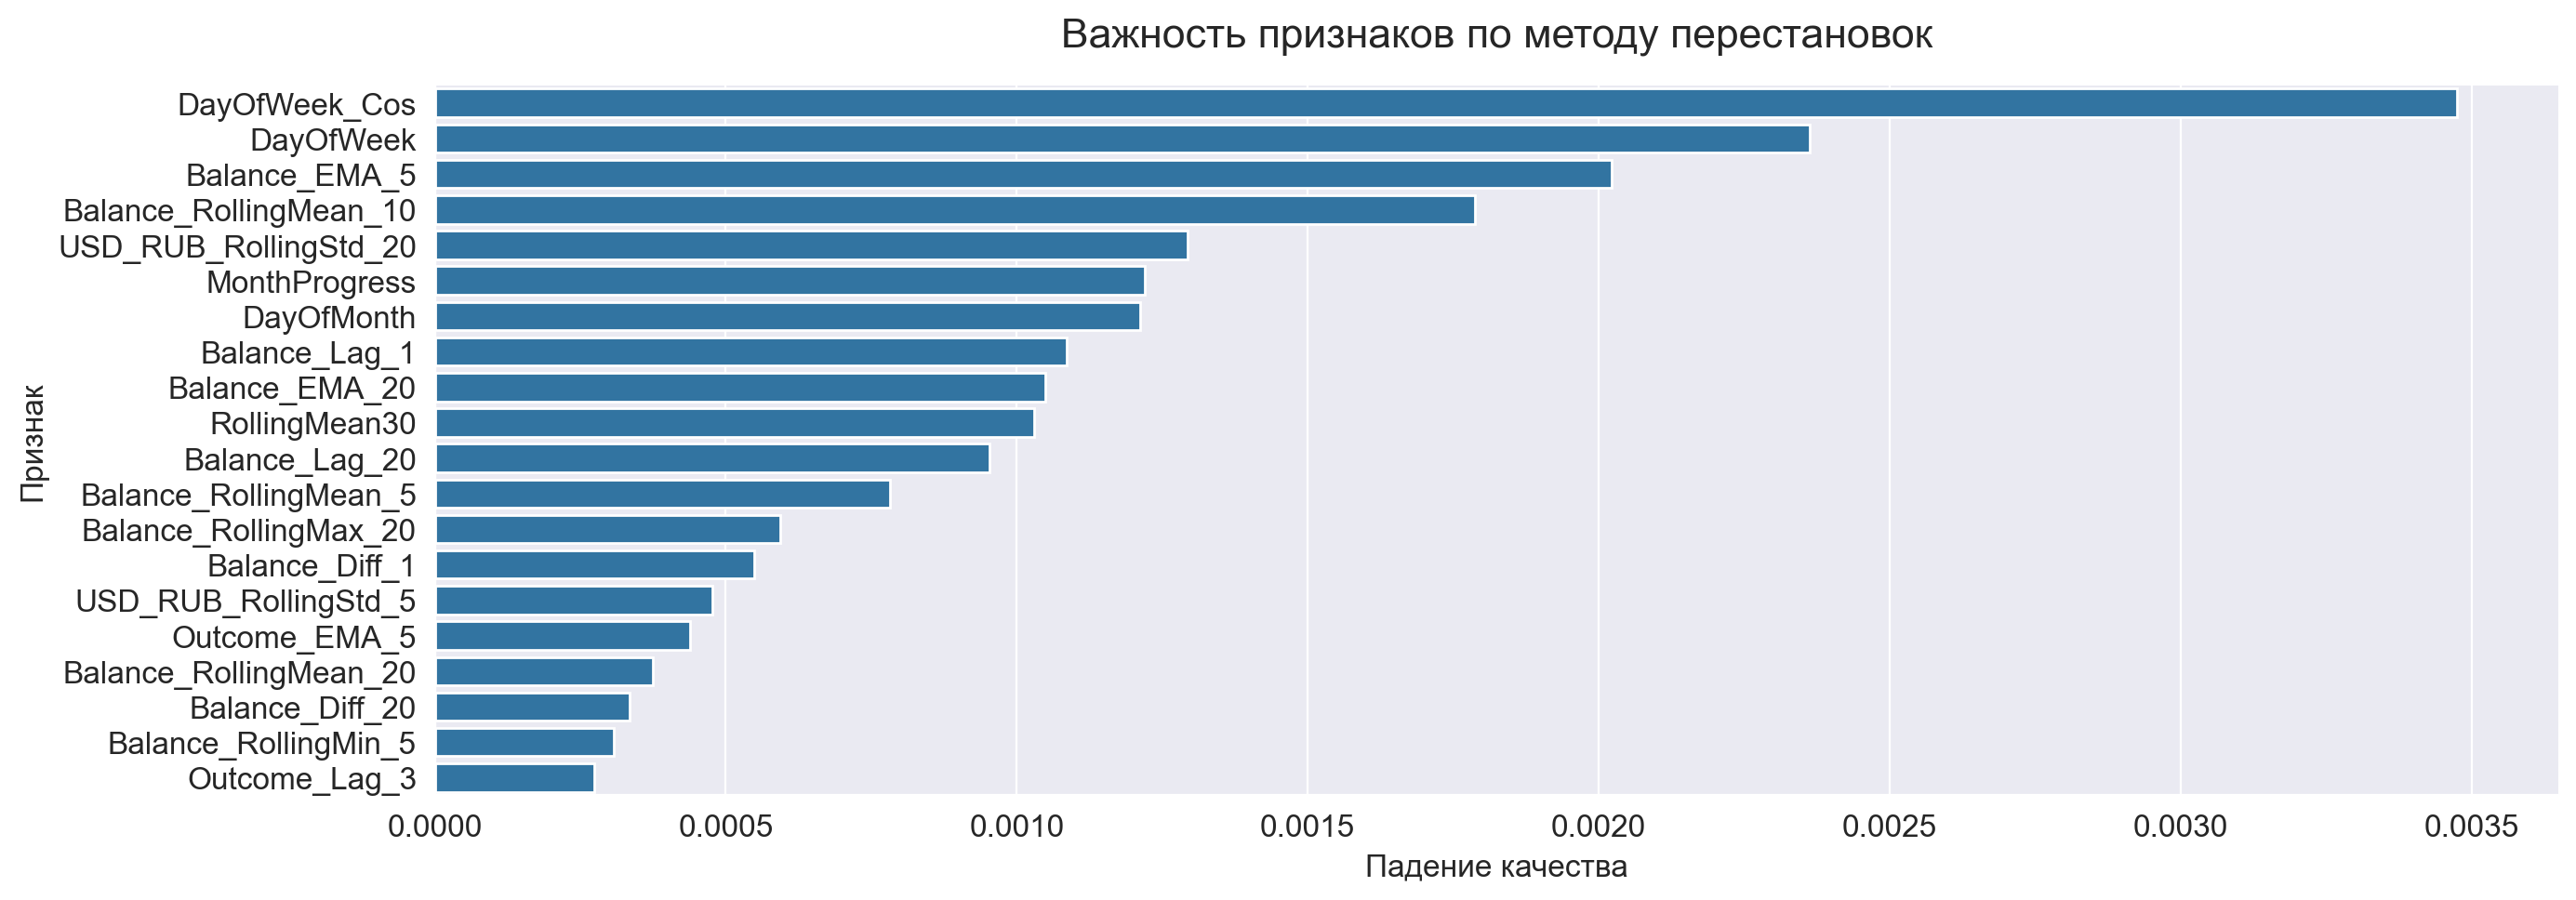

In [42]:
perm_importance_df_macro = get_permutation_importance(model=cat_model_macro, X=X_test_macro, y=y_test_macro, n_repeats=20)

sns.barplot(data=perm_importance_df_macro.head(20), x="Importance", y="Feature")
plt.title("Важность признаков по методу перестановок", pad=15)
plt.xlabel("Падение качества")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

### Среди макроэкономических признаков наибольшее влияние на прогноз оказывают лаги ключевой ставки, тогда как лаги курса USD/RUB менее значимы.
### Тем не менее, макропризнаки в целом уступают по важности лаговым признакам самого сальдо, что объясняет отсутствие прироста качества при их добавлении в модель.

# Отбор признаков (для модели CatBoost)

In [43]:
# Базовая модель
base_model = CatBoostRegressor(random_seed=42, verbose=False, loss_function="MAE", **cat_best_params)

# Сколько признаков берем
top_n = 20

In [44]:
# Фильтрационный метод: корреляция
corr_features, corr_scores = select_by_correlation(X=X_train, y=y_train, top_n=top_n)

corr_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=corr_features
)

corr_mae

0.21940639143963778

In [45]:
# Фильтрационный метод: взаимная информация
mi_features, mi_scores = select_by_mutual_information(
    X=X_train,
    y=y_train,
    top_n=top_n
)

mi_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=mi_features
)

mi_mae

0.20949760093620423

In [46]:
# Встроенный метод: Lasso
lasso_features, lasso_scores = select_by_lasso(X=X_train, y=y_train, top_n=top_n)

lasso_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=lasso_features
)

lasso_mae

0.2236926954141709

In [47]:
# Оберточный метод: permutation importance
perm_features, perm_scores = select_by_permutation(
    model=cat_model,
    X=X_test,
    y=y_test,
    top_n=top_n
)

perm_mae = evaluate_selected_features(
    model=base_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    selected_features=perm_features
)

perm_mae

0.20006661111128415

In [48]:
selection_results = pd.DataFrame({
    "Метод": [
        "Все признаки",
        "Корреляция",
        "Mutual Information",
        "Lasso",
        "Permutation Importance"
    ],
    "Категория": [
        "Без отбора",
        "Фильтрационный",
        "Фильтрационный (нелинейный)",
        "Встроенный",
        "Оберточный"
    ],
    "Количество признаков": [
        X_train.shape[1],
        len(corr_features),
        len(mi_features),
        len(lasso_features),
        len(perm_features)
    ],
    "MAE": [
        cat_metrics["MAE"],
        corr_mae,
        mi_mae,
        lasso_mae,
        perm_mae
    ]
})

selection_results

,Метод,Категория,Количество признаков,MAE
0,Все признаки,Без отбора,74,0.213561
1,Корреляция,Фильтрационный,20,0.219406
2,Mutual Information,Фильтрационный (нелинейный),20,0.209498
3,Lasso,Встроенный,20,0.223693
4,Permutation Importance,Оберточный,20,0.200067


In [49]:
tscv = TimeSeriesSplit(n_splits=5)

corr_selected_sets = []
lasso_selected_sets = []
perm_selected_sets = []
mi_selected_sets = []

for train_idx, valid_idx in tscv.split(X_train):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    X_fold_valid = X_train.iloc[valid_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    corr_features_fold, _ = select_by_correlation(
        X=X_fold_train,
        y=y_fold_train,
        top_n=top_n
    )

    mi_features_fold, _ = select_by_mutual_information(
        X=X_fold_train,
        y=y_fold_train,
        top_n=top_n
    )

    lasso_features_fold, _ = select_by_lasso(
        X=X_fold_train,
        y=y_fold_train,
        top_n=top_n
    )

    fold_model = CatBoostRegressor(
        random_seed=42,
        verbose=False,
        loss_function="MAE",
        **cat_best_params
    )

    fold_model.fit(X_fold_train, y_fold_train)

    perm_features_fold, _ = select_by_permutation(
        model=fold_model,
        X=X_fold_valid,
        y=y_fold_valid,
        top_n=top_n
    )

    corr_selected_sets.append(corr_features_fold)
    mi_selected_sets.append(mi_features_fold)
    lasso_selected_sets.append(lasso_features_fold)
    perm_selected_sets.append(perm_features_fold)


stability_results = pd.DataFrame({

    "Метод": [
        "Корреляция",
        "Mutual Information",
        "Lasso",
        "Permutation Importance"

    ],

    "Категория": [
        "Фильтрационный",
        "Фильтрационный (нелинейный)",
        "Встроенный",
        "Оберточный"
    ],

    "Индекс Кунчевой": [
        average_kuncheva(corr_selected_sets, X_train.shape[1]),
        average_kuncheva(mi_selected_sets, X_train.shape[1]),
        average_kuncheva(lasso_selected_sets, X_train.shape[1]),
        average_kuncheva(perm_selected_sets, X_train.shape[1])
    ]

})

stability_results

,Метод,Категория,Индекс Кунчевой
0,Корреляция,Фильтрационный,0.205185
1,Mutual Information,Фильтрационный (нелинейный),0.403889
2,Lasso,Встроенный,0.248986
3,Permutation Importance,Оберточный,0.136667


In [50]:
final_selection_summary = selection_results.merge(stability_results, on=["Метод", "Категория"], how="left")

final_selection_summary

,Метод,Категория,Количество признаков,MAE,Индекс Кунчевой
0,Все признаки,Без отбора,74,0.213561,NaN
1,Корреляция,Фильтрационный,20,0.219406,0.205185
2,Mutual Information,Фильтрационный (нелинейный),20,0.209498,0.403889
3,Lasso,Встроенный,20,0.223693,0.248986
4,Permutation Importance,Оберточный,20,0.200067,0.136667


### Лучший метод отбора признаков по качеству и стабильности - Mutual Information

In [51]:
mi_model, mi_result, mi_metrics = run_catboost(X_train=X_train[mi_features], y_train=y_train, X_test=X_test[mi_features], y_test=y_test, params=cat_best_params)

mi_result.index = test_dates.values
print(mi_metrics)

{'MAE': 0.20949760093620423}


### CatBoost с признаками, отобранными методом взаимной информации (20 из 74), показал MAE = 0.209 — незначительно лучше полной модели (0.214).
### Это подтверждает, что в исходном наборе из 74 признаков присутствует значительная доля избыточной информации: 20 наиболее информативных признаков не только сохраняют, но и слегка улучшают качество прогноза, вероятно за счёт снижения переобучения.

# Сравнение всех моделей и выбор лучшей

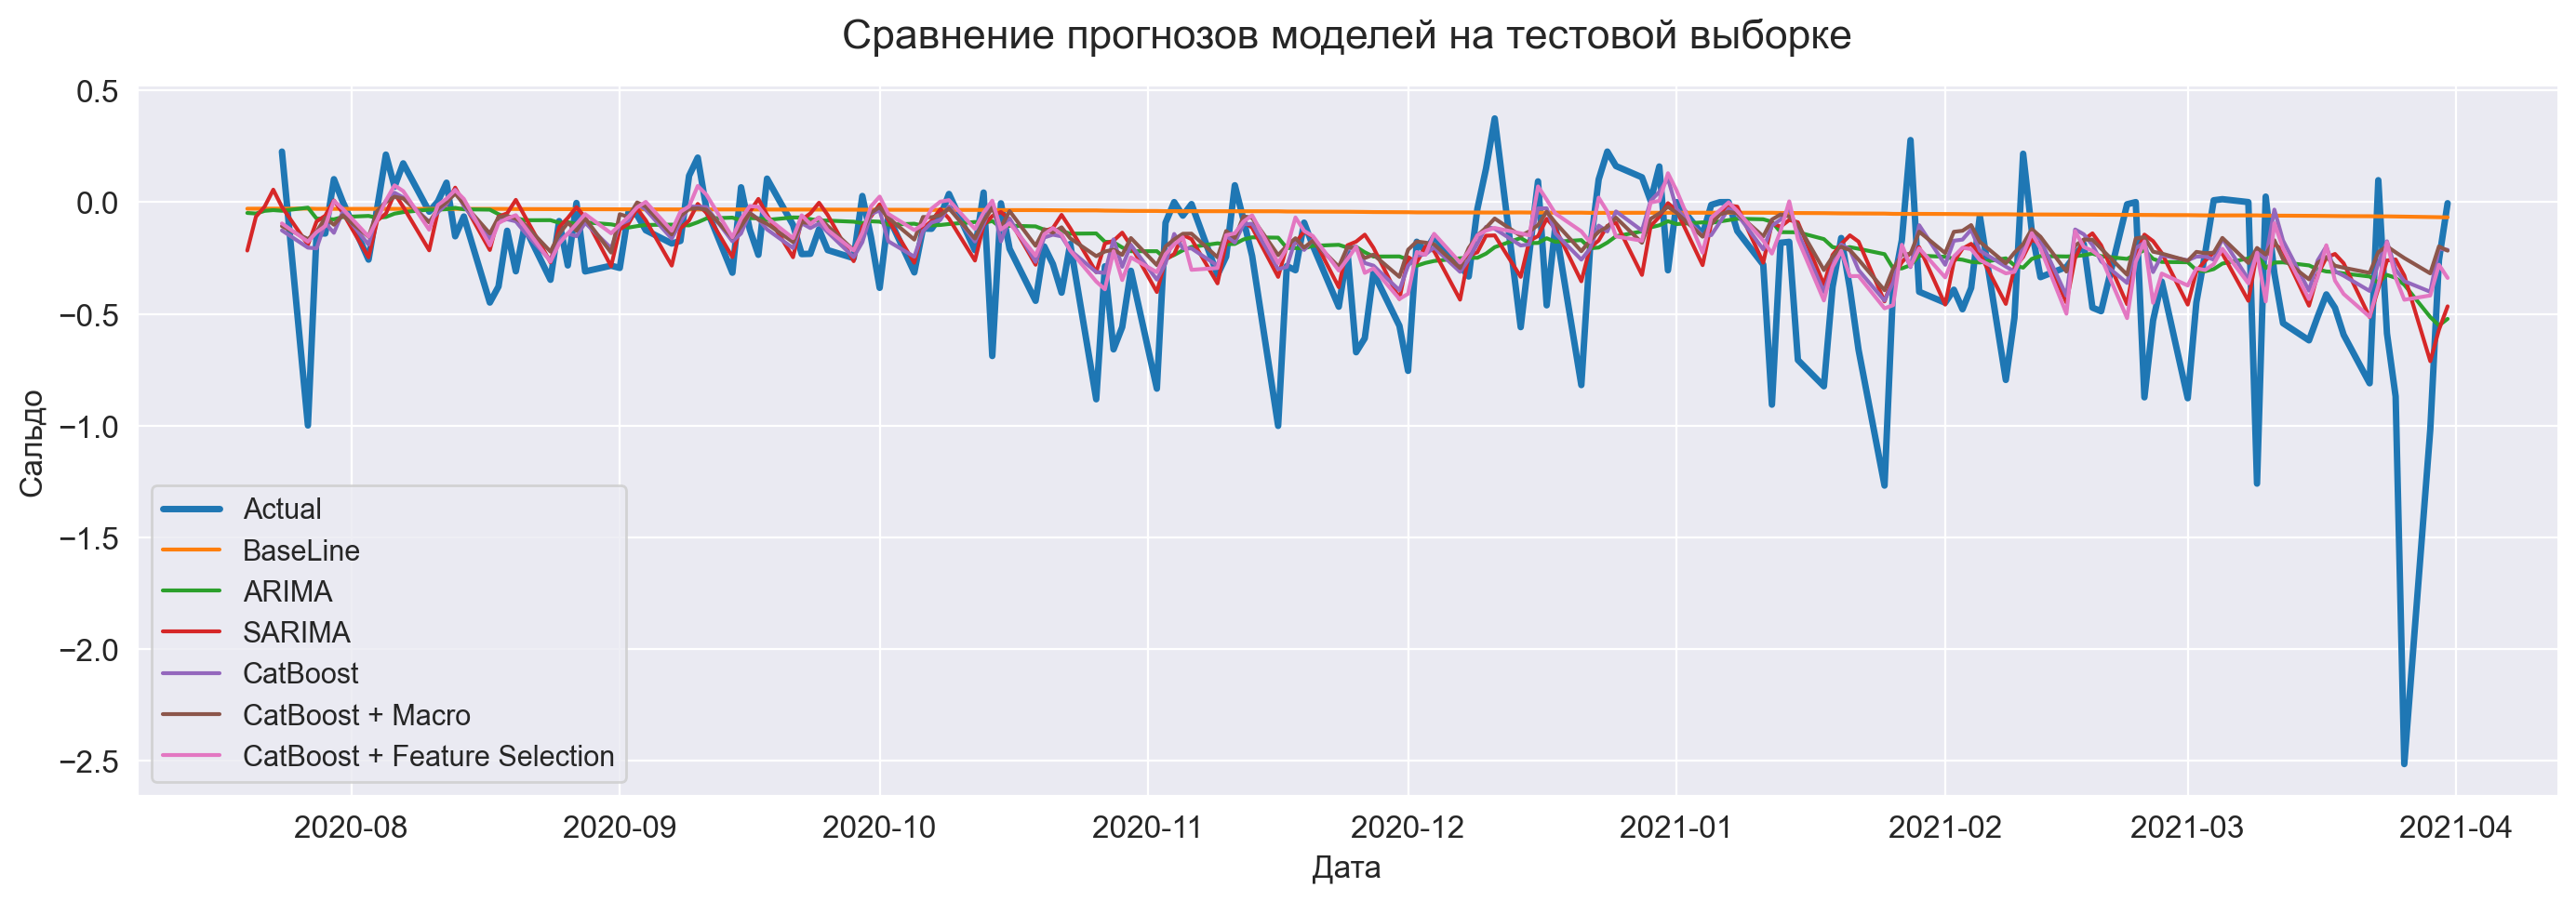

In [60]:
y_test.index = test_dates.values

plt.plot(
    y_test.index,
    y_test.values,
    linewidth=2.5,
    label="Actual"
)

plt.plot(
    baseline_result.index,
    baseline_result["Predicted"],
    label="BaseLine"
)

plt.plot(
    arima_result.index,
    arima_result["Predicted"],
    label="ARIMA"
)

plt.plot(
    sarima_result.index,
    sarima_result["Predicted"],
    label="SARIMA"
)

plt.plot(
    cat_result.index,
    cat_result["Predicted"],
    label="CatBoost"
)

plt.plot(
    cat_result_macro.index,
    cat_result_macro["Predicted"],
    label="CatBoost + Macro"
)

plt.plot(
    mi_result.index,
    mi_result["Predicted"],
    label="CatBoost + Feature Selection"
)

plt.title("Сравнение прогнозов моделей на тестовой выборке", pad=15)
plt.xlabel("Дата")
plt.ylabel("Сальдо")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
results_table = pd.DataFrame([
    {"Модель": "CatBoost + Feature Selection", "MAE": mi_metrics["MAE"]},
    {"Модель": "CatBoost",                     "MAE": cat_metrics["MAE"]},
    {"Модель": "SARIMA",                        "MAE": sarima_metrics["MAE"]},
    {"Модель": "Random Forest",                 "MAE": rf_metrics["MAE"]},
    {"Модель": "CatBoost + Macro",              "MAE": cat_metrics_macro["MAE"]},
    {"Модель": "ARIMA",                         "MAE": arima_metrics["MAE"]},
    {"Модель": "Baseline",                      "MAE": baseline_metrics["MAE"]},
]).sort_values("MAE").reset_index(drop=True)

results_table.index += 1
results_table["MAE"] = results_table["MAE"].round(4)

results_table

,Модель,MAE
1,CatBoost + Feature Selection,0.2095
2,CatBoost,0.2136
3,SARIMA,0.2156
4,Random Forest,0.2183
5,CatBoost + Macro,0.2219
6,ARIMA,0.2323
7,Baseline,0.2807


## Выводы:
### Лучшая модель по точности - CatBoost с отбором признаков
### Но по простоте использования, настройке, подготовки данных и времени калибровки SARIMA лучшая модель из всех. С учетом того, что точность у нее не сильно ниже чем у других моделе,ее и будем использовать в автоматизированном пайплайне